# Практичне завдання 2: Логістична регресія та федеративне навчання

## Мета роботи
Реалізувати багатокласову логістичну регресію засобами numpy, зрозуміти принципи 
федеративного навчання (FedAvg), коректно розподілити дані між клієнтами та сервером, 
дослідити вплив неоднорідності даних (Non-IID) та кількості локальних епох на якість 
глобальної моделі.

## Обґрунтування вибору датасету
Обрано **[Dry Bean Dataset](https://www.kaggle.com/datasets/muratkokludataset/dry-bean-dataset?resource=download)** (Kaggle, Murat Koklu) з таких причин:

- **Багатокласова задача (7 класів)**: на відміну від бінарної класифікації, тут повністю 
  задіюється механіка softmax-регресії — багатовимірні логіти, векторизована нормалізація 
  ймовірностей по рядках.
- **Природний дисбаланс класів**: від домінуючих DERMASON (~26%) та SIRA (~19%) до 
  рідкісного BOMBAY (~3.8%) — це хороший тест для macro-усереднених метрик (Macro-F1, 
  Balanced Accuracy) на противагу звичайній Accuracy.
- **Виражена мультиколінеарність ознак**: кілька геометричних дескрипторів (Area, 
  Perimeter, ConvexArea, EquivDiameter) походять з однієї фізичної природи форми зерна і 
  сильно корелюють (r > 0.95) — гарний випадок для дослідження Ridge-регуляризації.
- **Реалістичність федеративного сценарію**: дані можна логічно уявити як зібрані з різних 
  ферм/регіонів вирощування, що природно моделює Non-IID розподіл через Dirichlet-розподіл.

## Налаштування середовища та відтворюваність

Фіксуємо random seed для відтворюваності всіх результатів (розбиття, ініціалізація ваг, 
розподіл даних між клієнтами).

In [1]:
import os
from pathlib import Path
import copy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, balanced_accuracy_score,
    log_loss, confusion_matrix
)

%matplotlib inline
np.random.seed(42)
RANDOM_STATE = 42

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_context("notebook")

In [2]:
DATA_PATH = "data/Dry_Bean_Dataset.xlsx"
SHEET_NAME = "Dry_Beans_Dataset"      # назва листа в Excel-файлі; якщо інша - зміни

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"Файл датасету не знайдено за шляхом '{DATA_PATH}'. "
        f"Перевір шлях або поклади файл у ту саму папку, що й ноутбук."
    )

df = pd.read_excel(DATA_PATH, sheet_name=SHEET_NAME)

print(f"Розмір датасету: {df.shape}")
df.head()

Розмір датасету: (13611, 17)


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


In [3]:
FEATURE_COLUMNS = [
    "Area", "Perimeter", "MajorAxisLength", "MinorAxisLength", "AspectRation",
    "Eccentricity", "ConvexArea", "EquivDiameter", "Extent", "Solidity",
    "roundness", "Compactness", "ShapeFactor1", "ShapeFactor2",
    "ShapeFactor3", "ShapeFactor4"
]
TARGET_COLUMN = "Class"

class_to_id = {
    "SEKER": 0, "BARBUNYA": 1, "BOMBAY": 2, "CALI": 3,
    "HOROZ": 4, "SIRA": 5, "DERMASON": 6,
}
id_to_class = {v: k for k, v in class_to_id.items()}

# Перевірки цілісності датасету
assert df.shape[0] > 0, "Датасет порожній."
assert df.isnull().sum().sum() == 0, "У датасеті є пропущені значення."
assert set(FEATURE_COLUMNS).issubset(df.columns), (
    f"Відсутні ознаки: {set(FEATURE_COLUMNS) - set(df.columns)}"
)
assert TARGET_COLUMN in df.columns, "Відсутня цільова колонка 'Class'."
assert df[TARGET_COLUMN].nunique() == 7, (
    f"Очікується 7 класів, знайдено {df[TARGET_COLUMN].nunique()}."
)

print("Пропущені значення по колонках:")
print(df.isnull().sum())

print("\nРозподіл класів:")
print(df[TARGET_COLUMN].value_counts())

Пропущені значення по колонках:
Area               0
Perimeter          0
MajorAxisLength    0
MinorAxisLength    0
AspectRation       0
Eccentricity       0
ConvexArea         0
EquivDiameter      0
Extent             0
Solidity           0
roundness          0
Compactness        0
ShapeFactor1       0
ShapeFactor2       0
ShapeFactor3       0
ShapeFactor4       0
Class              0
dtype: int64

Розподіл класів:
Class
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1928
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: count, dtype: int64


## Розділ 1: Дослідницький аналіз даних (EDA)

Перед будь-якою обробкою потрібно зрозуміти структуру датасету: типи ознак, наявність 
пропусків, розподіл цільової змінної, основні статистики та кореляції між ознаками.
Це виконується на **повному** датасеті лише в описовому/ознайомчому сенсі — жодне 
розбиття, масштабування чи відбір ознак на цьому етапі ще не "навчається" на даних.

In [4]:
print("Типи даних та кількість непорожніх значень:")
df.info()

print("\nОсновні статистики числових ознак:")
df[FEATURE_COLUMNS].describe().round(4)

Типи даних та кількість непорожніх значень:
<class 'pandas.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRation     13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  float64
 16  Class            13611 no

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
count,13611.0000,13611.0000,13611.0000,13611.0000,13611.0000,13611.0000,13611.0000,13611.0000,13611.0000,13611.0000,13611.0000,13611.0000,13611.0000,13611.0000,13611.0000,13611.0000
mean,53048.2845,855.2835,320.1419,202.2707,1.5832,0.7509,53768.2002,253.0642,0.7497,0.9871,0.8733,0.7999,0.0066,0.0017,0.6436,0.9951
std,29324.0957,214.2897,85.6942,44.9701,0.2467,0.0920,29774.9158,59.1771,0.0491,0.0047,0.0595,0.0617,0.0011,0.0006,0.0990,0.0044
min,20420.0000,524.7360,183.6012,122.5127,1.0249,0.2190,20684.0000,161.2438,0.5553,0.9192,0.4896,0.6406,0.0028,0.0006,0.4103,0.9477
25%,36328.0000,703.5235,253.3036,175.8482,1.4323,0.7159,36714.5000,215.0680,0.7186,0.9857,0.8321,0.7625,0.0059,0.0012,0.5814,0.9937
50%,44652.0000,794.9410,296.8834,192.4317,1.5511,0.7644,45178.0000,238.4380,0.7599,0.9883,0.8832,0.8013,0.0066,0.0017,0.6420,0.9964
75%,61332.0000,977.2130,376.4950,217.0317,1.7071,0.8105,62294.0000,279.4465,0.7869,0.9900,0.9169,0.8343,0.0073,0.0022,0.6960,0.9979
max,254616.0000,1985.3700,738.8602,460.1985,2.4303,0.9114,263261.0000,569.3744,0.8662,0.9947,0.9907,0.9873,0.0105,0.0037,0.9748,0.9997


Розподіл цільової змінної

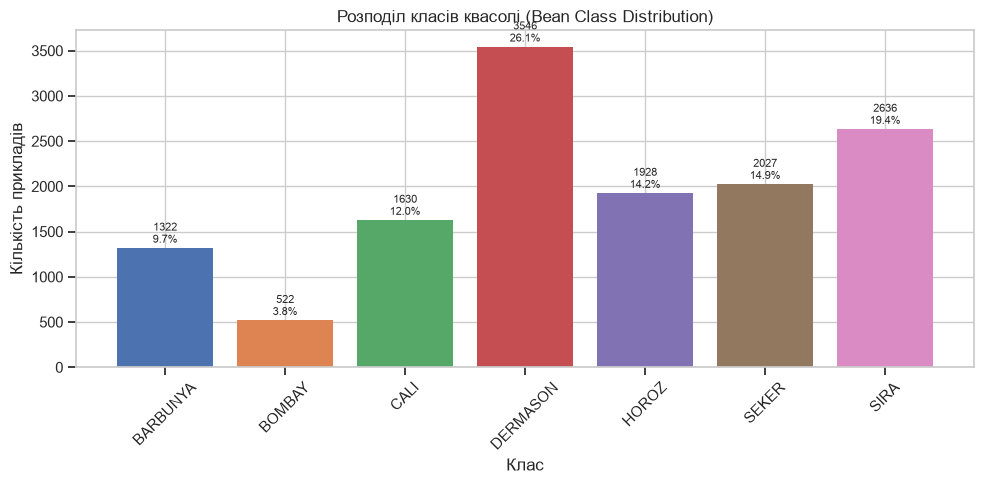

In [5]:
counts = df[TARGET_COLUMN].value_counts().sort_index()
percentages = counts / counts.sum() * 100

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(counts.index, counts.values, color=sns.color_palette("deep", len(counts)))
ax.set_title("Розподіл класів квасолі (Bean Class Distribution)")
ax.set_xlabel("Клас")
ax.set_ylabel("Кількість прикладів")

for i, (label, value) in enumerate(counts.items()):
    ax.text(i, value + 20, f"{value}\n{percentages[label]:.1f}%",
            ha="center", va="bottom", fontsize=8)

ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

Кореляційна матриця

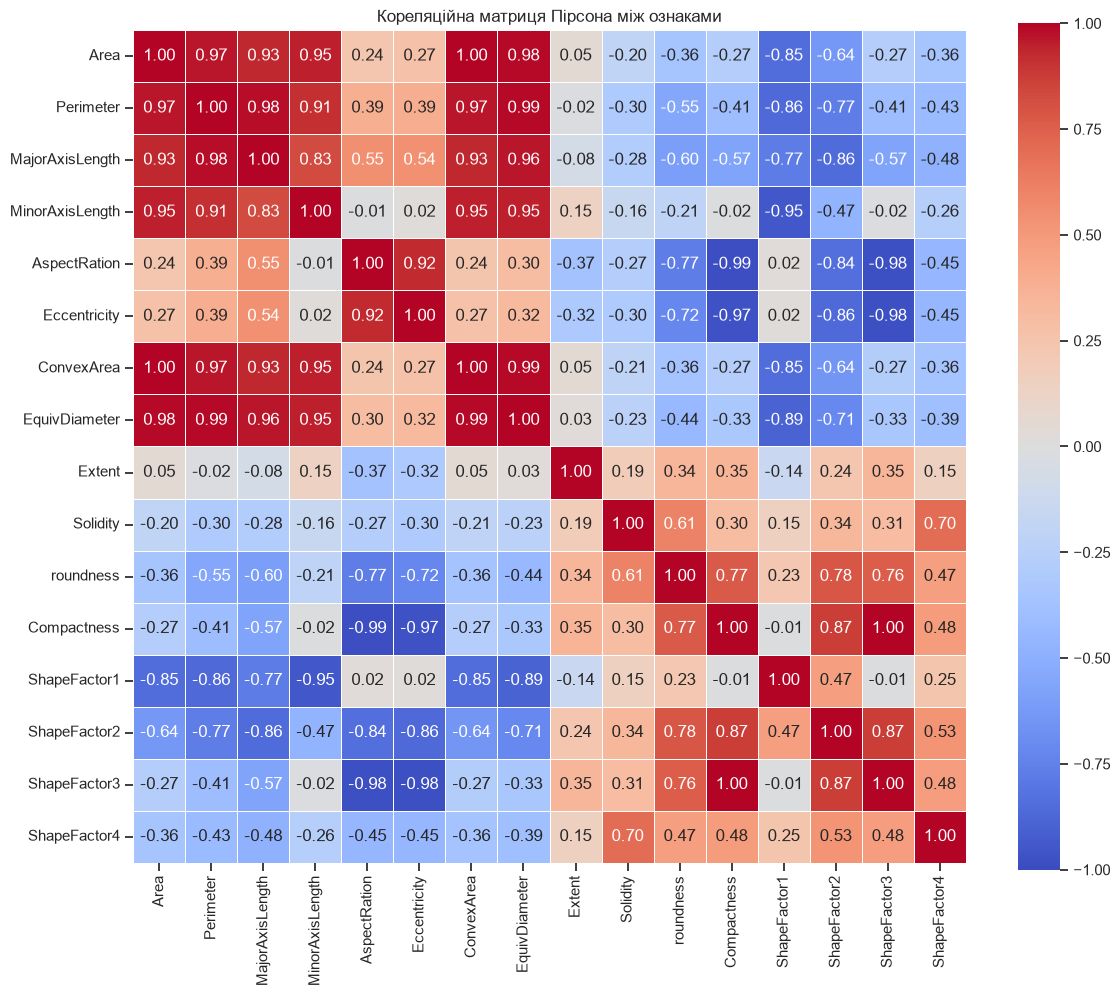

Пари ознак із |кореляція| > 0.95:
Area             ConvexArea       0.999939
Compactness      ShapeFactor3     0.998686
EquivDiameter    Perimeter        0.991380
AspectRation     Compactness      0.987687
EquivDiameter    ConvexArea       0.985226
                 Area             0.984968
ShapeFactor3     Eccentricity     0.981058
AspectRation     ShapeFactor3     0.978592
MajorAxisLength  Perimeter        0.977338
Compactness      Eccentricity     0.970313
ConvexArea       Perimeter        0.967689
Area             Perimeter        0.966722
MajorAxisLength  EquivDiameter    0.961733
MinorAxisLength  Area             0.951602
                 ConvexArea       0.951339
dtype: float64


In [6]:
corr = df[FEATURE_COLUMNS].corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, cmap="coolwarm", vmin=-1, vmax=1, annot=True, fmt=".2f", linewidths=0.5,
    square=True, ax=ax)

ax.set_title("Кореляційна матриця Пірсона між ознаками")
plt.tight_layout()
plt.show()

# Виведемо пари ознак з дуже високою кореляцією (потенційна мультиколінеарність)
corr_pairs = corr.abs().unstack()
corr_pairs = corr_pairs[corr_pairs < 1.0].sort_values(ascending=False)
high_corr = corr_pairs[corr_pairs > 0.95].drop_duplicates()
print("Пари ознак із |кореляція| > 0.95:")
print(high_corr)

### Висновок з EDA

**Розподіл класів.** Датасет має виражений дисбаланс: клас DERMASON становить понад чверть 
усіх прикладів (~26%), тоді як BOMBAY — лише ~3.8%. Це означає, що звичайна Accuracy може 
вводити в оману (модель, що завжди передбачає найбільший клас, матиме високу Accuracy, 
але низьку якість на рідкісних класах). Тому в подальшому оцінюванні пріоритет 
надається Macro-F1 та Balanced Accuracy.

**Мультиколінеарність.** Кілька геометричних ознак (Area, Perimeter, ConvexArea, 
MajorAxisLength, EquivDiameter) демонструють кореляцію |r| > 0.95 між собою — це очікувано, 
оскільки всі вони математично похідні від фізичного розміру зерна (площа, периметр, 
еквівалентний діаметр — все виводиться з одних і тих самих геометричних вимірів контуру). 

Сильна мультиколінеарність не обов'язково шкодить точності прогнозу, але вона розтягує 
поверхню функції втрат уздовж корельованих напрямків, що ускладнює градієнтний спуск і 
може призводити до нестабільно великих ваг. Тому надалі ми дослідимо вплив Ridge (L2) 
регуляризації, яка стягує корельовані ваги разом, замість того щоб дозволяти їм "вибухати".

**Рішення щодо ознак.** Усі 16 ознак залишаємо в моделі: кожна несе часткову додаткову 
інформацію про форму зерна, а видалення ознак ризикує втратити частину роздільної 
здатності між класами. Мультиколінеарність натомість контролюється регуляризацією, а не 
відбором ознак — це буде емпірично перевірено на етапі підбору гіперпараметрів.

## Розділ 2: Розбиття вибірки

Перш ніж виконувати будь-яке масштабування, кодування чи інші операції, що "навчаються" 
на даних, потрібно розбити дані на три частини:

- **Global Test (20%)** — зберігається на сервері, використовується **лише один раз** для 
  фінальної оцінки якості моделі.
- **Global Validation (10%)** — використовується для підбору гіперпараметрів та порівняння 
  моделей (централізованої та федеративних). Клієнтам не передається.
- **FL Train Pool (решта, ~70%)** — розподіляється між клієнтами у федеративному навчанні.

Розбиття стратифіковане за класами (`stratify=y`), щоб пропорції класів зберігалися 
однаковими в усіх трьох підвибірках.

### Чому розбиття має передувати масштабуванню/кодуванню? Що таке Data Leakage?

**Data Leakage (витік даних)** — це ситуація, коли інформація з валідаційної або тестової 
вибірки випадково потрапляє в процес навчання моделі: через параметри масштабування, 
кодування категорій, відбір ознак чи підбір гіперпараметрів.

Якщо обчислити середнє й дисперсію (для StandardScaler) на **всьому** датасеті, а потім 
розбити на train/val/test — тестова вибірка вже "вплинула" на параметри масштабування, 
які застосовуються і до неї самої. Модель фактично отримує непряму інформацію про 
розподіл тестових даних ще до того, як має бути оцінена на них. Це призводить до 
оптимістично завищених (нечесних) метрик якості, які не відображають реальну здатність 
моделі узагальнювати на нових, справді небачених даних.

Тому правильний порядок:
1. Спочатку розбити на Global Test / Global Validation / FL Train Pool.
2. Лише потім обчислювати статистики масштабування — **виключно на FL Train Pool**.
3. Застосовувати ці ж статистики (не перенавчені) до Validation та Test.

Розбиття

In [7]:
X = df[FEATURE_COLUMNS].values.astype(np.float64)
y = df[TARGET_COLUMN].values

# Спочатку відокремлюємо Global Test (20%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

# З решти (80%) відокремлюємо Global Validation (12.5% від 80% = 10% від повного датасету)
X_train_pool, X_val, y_train_pool, y_val = train_test_split(
    X_temp, y_temp, test_size=0.125, stratify=y_temp, random_state=RANDOM_STATE
)

assert abs(len(X_train_pool) / len(X) - 0.70) < 0.02, "FL Train Pool має бути ~70%."
assert abs(len(X_val) / len(X) - 0.10) < 0.02, "Global Validation має бути ~10%."
assert abs(len(X_test) / len(X) - 0.20) < 0.02, "Global Test має бути ~20%."

print(f"Всього прикладів: {len(X)}")
print(f"FL Train Pool: {len(X_train_pool)} ({len(X_train_pool) / len(X) * 100:.2f}%)")
print(f"Global Validation: {len(X_val)} ({len(X_val) / len(X) * 100:.2f}%)")
print(f"Global Test: {len(X_test)} ({len(X_test) / len(X) * 100:.2f}%)")

Всього прикладів: 13611
FL Train Pool: 9527 (69.99%)
Global Validation: 1361 (10.00%)
Global Test: 2723 (20.01%)


Перевірка збереження пропорцій класів

In [8]:
def class_distribution_pct(y_arr):
    vals, counts = np.unique(y_arr, return_counts=True)
    return pd.Series(counts / counts.sum() * 100, index=vals).round(2)

dist_check = pd.DataFrame({
    "Full dataset": class_distribution_pct(y),
    "FL Train Pool": class_distribution_pct(y_train_pool),
    "Global Validation": class_distribution_pct(y_val),
    "Global Test": class_distribution_pct(y_test),
})
print("Порівняння розподілу класів (%) у кожній підвибірці:")
dist_check

Порівняння розподілу класів (%) у кожній підвибірці:


,Full dataset,FL Train Pool,Global Validation,Global Test
BARBUNYA,9.71,9.71,9.70,9.73
BOMBAY,3.84,3.84,3.82,3.82
CALI,11.98,11.98,11.98,11.97
DERMASON,26.05,26.05,26.08,26.04
HOROZ,14.17,14.16,14.18,14.18
SEKER,14.89,14.88,14.92,14.91
SIRA,19.37,19.38,19.32,19.35


## Розділ 3: Кодування категоріальних ознак та масштабування

### Категоріальні ознаки
Усі 16 вхідних ознак у Dry Bean Dataset є числовими (фізичні виміри зерен), тому етап 
кодування категоріальних ознак (One-Hot / Ordinal / Target Encoding) для вхідних даних 
**не застосовується**. 

Єдина категоріальна змінна — цільова (`Class`), яку ми кодуємо в one-hot формат, оскільки 
цього вимагає softmax + крос-ентропійна функція втрат багатокласової логістичної регресії.

### Масштабування
Застосовуємо стандартизацію (`StandardScaler`, тобто z-score: віднімання середнього та 
ділення на стандартне відхилення) до числових ознак.

Обираємо **спрощений підхід**, зазначений у завданні як допустимий: скейлер навчається на 
всьому **FL Train Pool до** розподілу даних між клієнтами. Це свідомо спрощує симуляцію 
(в реальній федеративній системі кожен клієнт обчислював би локальні статистики, а сервер 
агрегував би їх зважено) — але дозволяє зосередитись на головній меті роботи: коректній 
архітектурі розподілу даних, реалізації FedAvg та аналізі ефектів неоднорідності.

Критично важливо: параметри масштабування (середнє, дисперсія) обчислюються **лише на 
FL Train Pool**, а потім ці самі параметри застосовуються (не перенавчаються!) до 
Global Validation та Global Test — це і є правильний спосіб уникнути Data Leakage 
на етапі препроцесингу.

Масштабування

In [9]:
scaler = StandardScaler()
X_train_pool = scaler.fit_transform(X_train_pool)   # fit ТІЛЬКИ на train pool
X_val = scaler.transform(X_val)                      # тільки transform
X_test = scaler.transform(X_test)                    # тільки transform

print("Середні значення ознак після масштабування (train pool, мають бути ~0):")
print(np.round(X_train_pool.mean(axis=0), 4))
print("\nСтандартні відхилення (train pool, мають бути ~1):")
print(np.round(X_train_pool.std(axis=0), 4))

Середні значення ознак після масштабування (train pool, мають бути ~0):
[-0.  0. -0.  0.  0.  0. -0.  0.  0. -0. -0. -0. -0. -0. -0.  0.]

Стандартні відхилення (train pool, мають бути ~1):
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


One-hot кодування цільової змінної

In [10]:
num_classes = len(class_to_id)

def one_hot_encode(labels, class_to_id_map):
    out = np.zeros((len(labels), len(class_to_id_map)), dtype=np.float64)
    for i, label in enumerate(labels):
        out[i, class_to_id_map[label]] = 1.0
    return out

Y_train_pool = one_hot_encode(y_train_pool, class_to_id)
Y_val = one_hot_encode(y_val, class_to_id)
Y_test = one_hot_encode(y_test, class_to_id)

# Цілочислові мітки (знадобляться для метрик sklearn)
y_train_pool_int = np.array([class_to_id[label] for label in y_train_pool], dtype=np.int64)
y_val_int = np.array([class_to_id[label] for label in y_val], dtype=np.int64)
y_test_int = np.array([class_to_id[label] for label in y_test], dtype=np.int64)

# Перевірки коректності форм і відсутності NaN/Inf
assert np.isfinite(X_train_pool).all(), "X_train_pool містить NaN/Inf."
assert np.isfinite(X_val).all(), "X_val містить NaN/Inf."
assert np.isfinite(X_test).all(), "X_test містить NaN/Inf."
assert X_train_pool.shape == (len(y_train_pool), 16)
assert Y_train_pool.shape == (len(y_train_pool), 7)

print(f"X_train_pool: {X_train_pool.shape}, Y_train_pool: {Y_train_pool.shape}")
print(f"X_val: {X_val.shape}, Y_val: {Y_val.shape}")
print(f"X_test: {X_test.shape}, Y_test: {Y_test.shape}")

X_train_pool: (9527, 16), Y_train_pool: (9527, 7)
X_val: (1361, 16), Y_val: (1361, 7)
X_test: (2723, 16), Y_test: (2723, 7)


## Розділ 4: Реалізація багатокласової логістичної регресії (numpy)

### Математична постановка

Нехай $X \in \mathbb{R}^{m \times d}$ — матриця об'єктів ($m$ прикладів, $d$ ознак), 
$Y \in \{0,1\}^{m \times C}$ — one-hot мітки ($C$ класів).

Параметри моделі: $W \in \mathbb{R}^{d \times C}$, $b \in \mathbb{R}^{1 \times C}$.

**Лінійна частина:** $Z = XW + b$

**Softmax:** $P_{ic} = \dfrac{\exp(Z_{ic})}{\sum_{j=1}^{C} \exp(Z_{ij})}$

Для числової стабільності перед експонуванням віднімаємо максимум кожного рядка 
($Z_i - \max_j Z_{ij}$) — це не змінює результат softmax математично (чисельник і 
знаменник масштабуються однаково), але запобігає переповненню `exp()` для великих логітів.

**Функція втрат (крос-ентропія) з Ridge-регуляризацією:**

$$J(W,b) = -\frac{1}{m}\sum_{i=1}^{m}\sum_{c=1}^{C} Y_{ic}\log P_{ic} + \frac{\lambda}{2}\|W\|_F^2$$

Параметр зміщення $b$ не регуляризується (пояснення — у теоретичних питаннях).

**Градієнти:**
$$\frac{\partial J}{\partial W} = \frac{1}{m}X^\top(P-Y) + \lambda W, \qquad 
\frac{\partial J}{\partial b} = \frac{1}{m}\mathbf{1}_m^\top(P-Y)$$

Реалізація повністю векторизована — без циклів `for` по прикладах (циклами дозволено йти 
лише по епохах/батчах/клієнтах).

Клас моделі

In [11]:
class SoftmaxLogisticRegression:
    """
    Багатокласова логістична регресія (softmax regression), реалізована
    повністю засобами numpy, з підтримкою Ridge (L2) регуляризації та
    mini-batch градієнтного спуску.
    """

    def __init__(self, learning_rate=0.1, epochs=50, batch_size=64,
                 l2_lambda=0.001, random_state=42):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.batch_size = batch_size
        self.l2_lambda = l2_lambda
        self.random_state = random_state

        self.W = None
        self.b = None
        self.train_loss_history = []
        self.val_loss_history = []
        self.val_accuracy_history = []

    def _softmax(self, Z):
        # Віднімання максимуму рядка для числової стабільності
        Z_shifted = Z - np.max(Z, axis=1, keepdims=True)
        exp_logits = np.exp(Z_shifted)
        return exp_logits / np.sum(exp_logits, axis=1, keepdims=True)

    def _compute_loss(self, X, Y, W, b):
        Z = X @ W + b
        P = self._softmax(Z)
        epsilon = 1e-12  # захист від log(0)
        loss = -(1.0 / X.shape[0]) * np.sum(Y * np.log(P + epsilon))
        l2_term = 0.5 * self.l2_lambda * np.sum(W ** 2)
        return loss + l2_term

    def _compute_gradients(self, X, Y, P, W):
        m = X.shape[0]
        dW = (1.0 / m) * (X.T @ (P - Y)) + self.l2_lambda * W
        db = (1.0 / m) * np.sum(P - Y, axis=0, keepdims=True)
        return dW, db

    def fit(self, X, Y, X_val=None, Y_val=None, init_weights=True):
        X = np.asarray(X, dtype=np.float64)
        Y = np.asarray(Y, dtype=np.float64)
        n_samples, n_features = X.shape
        n_classes = Y.shape[1]

        rng = np.random.RandomState(self.random_state)

        if self.W is None or init_weights:
            self.W = rng.normal(0.0, 0.01, size=(n_features, n_classes))
            self.b = np.zeros((1, n_classes), dtype=np.float64)
            self.train_loss_history = []
            self.val_loss_history = []
            self.val_accuracy_history = []

        for epoch in range(self.epochs):
            permutation = rng.permutation(n_samples)
            X_shuffled = X[permutation]
            Y_shuffled = Y[permutation]

            # Цикл по міні-батчах (дозволений завданням)
            for start in range(0, n_samples, self.batch_size):
                end = min(start + self.batch_size, n_samples)
                X_batch = X_shuffled[start:end]
                Y_batch = Y_shuffled[start:end]

                P_batch = self._softmax(X_batch @ self.W + self.b)
                dW, db = self._compute_gradients(X_batch, Y_batch, P_batch, self.W)

                self.W -= self.learning_rate * dW
                self.b -= self.learning_rate * db

            train_loss = self._compute_loss(X, Y, self.W, self.b)
            self.train_loss_history.append(train_loss)

            if X_val is not None and Y_val is not None:
                val_loss = self._compute_loss(X_val, Y_val, self.W, self.b)
                val_pred = self.predict(X_val)
                val_true = np.argmax(Y_val, axis=1)
                val_acc = accuracy_score(val_true, val_pred)
                self.val_loss_history.append(val_loss)
                self.val_accuracy_history.append(val_acc)

        return self

    def predict_proba(self, X):
        X = np.asarray(X, dtype=np.float64)
        Z = X @ self.W + self.b
        return self._softmax(Z)

    def predict(self, X):
        probs = self.predict_proba(X)
        return np.argmax(probs, axis=1).astype(np.int64)

    def get_params(self):
        return copy.deepcopy(self.W), copy.deepcopy(self.b)

    def set_params(self, W, b):
        self.W = copy.deepcopy(W)
        self.b = copy.deepcopy(b)
        return self

Швидка перевірка градієнтів

In [12]:
# Швидка перевірка: чи спадає loss на маленькій підвибірці за кілька епох
sanity_model = SoftmaxLogisticRegression(learning_rate=0.5, epochs=20, batch_size=32,
                                          l2_lambda=0.0, random_state=RANDOM_STATE)
sanity_model.fit(X_train_pool[:500], Y_train_pool[:500])

print("Loss на початку:", round(sanity_model.train_loss_history[0], 4))
print("Loss наприкінці:", round(sanity_model.train_loss_history[-1], 4))
assert sanity_model.train_loss_history[-1] < sanity_model.train_loss_history[0], \
    "Loss не спадає — перевір реалізацію градієнтів!"
print("✓ Санітарна перевірка пройдена: loss спадає.")

Loss на початку: 0.619
Loss наприкінці: 0.2087
✓ Санітарна перевірка пройдена: loss спадає.


## Розділ 5: Метрики оцінювання

Для багатокласової класифікації з дисбалансом класів використовуємо:
- **Accuracy** — частка правильних передбачень (може вводити в оману при дисбалансі).
- **Macro-F1** — середнє F1 по класах без урахування ваги класу (рівна увага кожному класу).
- **Balanced Accuracy** — середня recall по класах (стійка до дисбалансу).
- **Log Loss** — оцінює якість каліброваних ймовірностей, а не лише "переможний" клас.
- **Confusion Matrix** — детальна картина помилок між парами класів.

Функції оцінювання

In [13]:
def evaluate_model(model, X, y_true, id_to_class_map):
    y_true = np.asarray(y_true, dtype=np.int64)
    probas = model.predict_proba(X)
    y_pred = model.predict(X)

    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Macro-F1': f1_score(y_true, y_pred, average='macro'),
        'Balanced Accuracy': balanced_accuracy_score(y_true, y_pred),
        'Log Loss': log_loss(y_true, probas, labels=list(id_to_class_map.keys())),
        'Confusion Matrix': confusion_matrix(y_true, y_pred, labels=list(id_to_class_map.keys())),
    }


def plot_confusion_matrix(cm, class_names, title):
    fig, ax = plt.subplots(figsize=(8, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_xlabel('Передбачений клас')
    ax.set_ylabel('Справжній клас')
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

## Розділ 6: Централізована базова модель

Навчаємо логістичну регресію на **всьому** FL Train Pool (без розподілу між клієнтами) — 
це базова лінія (baseline), з якою порівнюватимуться федеративні моделі.

Підбір гіперпараметрів (швидкість навчання, розмір батчу, сила Ridge-регуляризації) 
виконується виключно на **Global Validation**. **Global Test використовується один раз**, 
лише для фінальної оцінки найкращої знайденої конфігурації.

In [14]:
param_grid = {
    'learning_rate': [0.05, 0.1],
    'batch_size': [64, 128],
    'l2_lambda': [0.0, 0.001, 0.01],
}

best_config = None
best_model = None
best_val_acc = -np.inf
best_val_loss = np.inf

for lr in param_grid['learning_rate']:
    for batch_size in param_grid['batch_size']:
        for l2_lambda in param_grid['l2_lambda']:
            model = SoftmaxLogisticRegression(
                learning_rate=lr, epochs=50, batch_size=batch_size,
                l2_lambda=l2_lambda, random_state=RANDOM_STATE
            )
            model.fit(X_train_pool, Y_train_pool, X_val=X_val, Y_val=Y_val)

            val_true = np.argmax(Y_val, axis=1)
            val_pred = model.predict(X_val)
            val_acc = accuracy_score(val_true, val_pred)
            val_loss = model._compute_loss(X_val, Y_val, model.W, model.b)

            # Обираємо конфігурацію з найкращою accuracy;
            # при рівності - з найменшим loss
            if val_acc > best_val_acc or (np.isclose(val_acc, best_val_acc) and val_loss < best_val_loss):
                best_val_acc = val_acc
                best_val_loss = val_loss
                best_config = {'learning_rate': lr, 'batch_size': batch_size, 'l2_lambda': l2_lambda}
                best_model = model

print('Найкраща конфігурація за Validation:')
print(best_config)
print(f'Найкраща validation accuracy: {best_val_acc:.4f}')
print(f'Найкращий validation loss: {best_val_loss:.4f}')

Найкраща конфігурація за Validation:
{'learning_rate': 0.1, 'batch_size': 64, 'l2_lambda': 0.0}
Найкраща validation accuracy: 0.9309
Найкращий validation loss: 0.1858


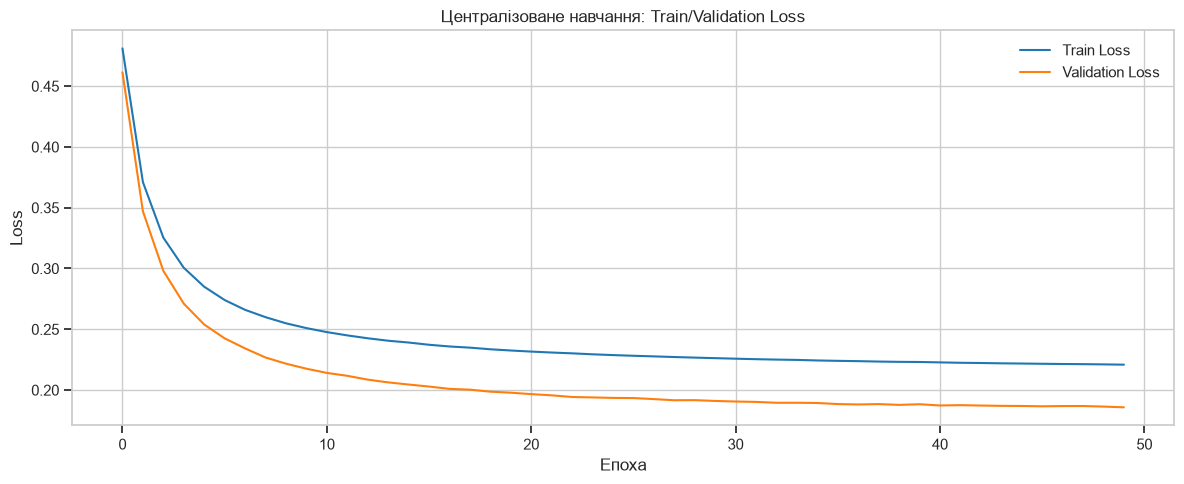

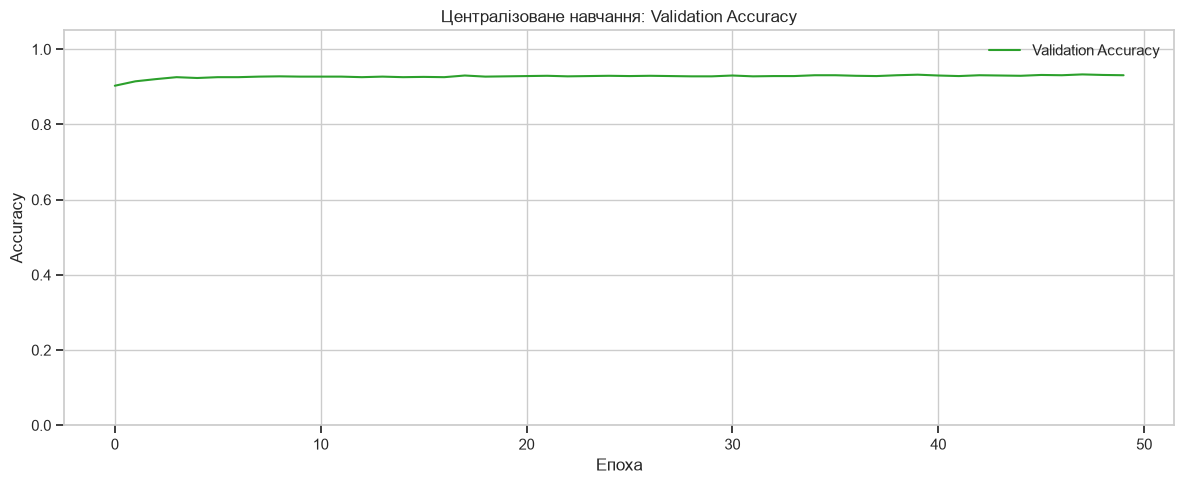

In [15]:
final_central_model = SoftmaxLogisticRegression(
    learning_rate=best_config['learning_rate'],
    epochs=50,
    batch_size=best_config['batch_size'],
    l2_lambda=best_config['l2_lambda'],
    random_state=RANDOM_STATE,
)
final_central_model.fit(X_train_pool, Y_train_pool, X_val=X_val, Y_val=Y_val)

# Графік Loss
plt.figure(figsize=(12, 5))
plt.plot(final_central_model.train_loss_history, label='Train Loss', color='tab:blue')
plt.plot(final_central_model.val_loss_history, label='Validation Loss', color='tab:orange')
plt.title('Централізоване навчання: Train/Validation Loss')
plt.xlabel('Епоха')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

# Графік Accuracy
plt.figure(figsize=(12, 5))
plt.plot(final_central_model.val_accuracy_history, label='Validation Accuracy', color='tab:green')
plt.title('Централізоване навчання: Validation Accuracy')
plt.xlabel('Епоха')
plt.ylabel('Accuracy')
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()
plt.show()

Фінальна оцінка на Global Test — лише один раз

Централізована модель на Global Test:
Accuracy: 0.9196
Macro-F1: 0.9315
Balanced Accuracy: 0.9302
Log Loss: 0.2195


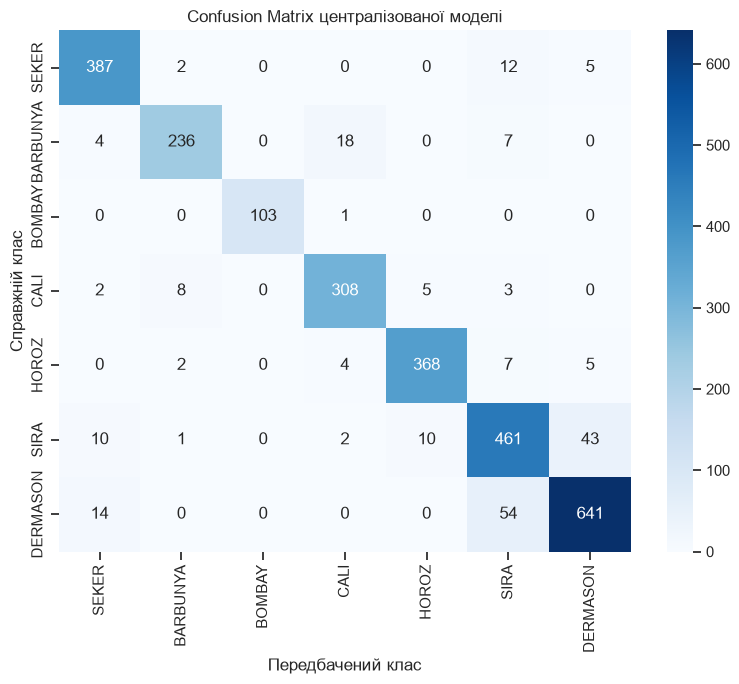

In [16]:
central_eval = evaluate_model(final_central_model, X_test, y_test_int, id_to_class)

print('Централізована модель на Global Test:')
for key, value in central_eval.items():
    if key == 'Confusion Matrix':
        continue
    print(f'{key}: {value:.4f}')

plot_confusion_matrix(central_eval['Confusion Matrix'], list(id_to_class.values()),
                       'Confusion Matrix централізованої моделі')

### Висновок

**Графіки Loss/Accuracy.** Training та Validation Loss швидко спадають протягом перших 
10–12 епох, після чого плавно виходять на плато (Loss ≈ 0.18–0.22) без розходження між 
кривими — ознак перенавчання не спостерігається. Validation Accuracy стабілізується на 
рівні ~92–93% вже після ~20 епохи. Швидка та стабільна збіжність пояснюється опуклою 
природою функції втрат багатокласової логістичної регресії — градієнтний спуск гарантовано 
сходиться до глобального мінімуму.

**Найкраща конфігурація.** Обрано learning_rate=0.1, batch_size=64, l2_lambda=0.0 
(validation accuracy = 0.9309, validation loss = 0.1858). Той факт, що оптимальним 
виявився нульовий коефіцієнт регуляризації, пояснюється тим, що стандартизація ознак 
(StandardScaler) вже сама по собі достатньо стабілізувала масштаб ваг і запобігла їх 
"вибуховому" зростанню навіть попри виражену мультиколінеарність, виявлену на етапі EDA. 
За 50 епох модель не встигає перенавчитися настільки, щоб додаткова Ridge-регуляризація 
дала виграш — навпаки, вона лише трохи "стискає" ваги, злегка погіршуючи підгонку.

**Метрики на Global Test.** Accuracy = 0.9196, Macro-F1 = 0.9315, Balanced Accuracy = 0.9302, 
Log Loss = 0.2195. Показово, що Macro-F1 та Balanced Accuracy **перевищують** звичайну 
Accuracy — це означає, що модель не жертвує якістю передбачень на малочисельних класах 
(зокрема BOMBAY) заради точності на домінуючих класах: лінійні межі рішення залишаються 
збалансованими попри дисбаланс класів у навчальних даних.

**Confusion Matrix.** Найбільша плутанина спостерігається між класами **SIRA та DERMASON**: 
43 приклади SIRA помилково класифіковано як DERMASON, і 54 приклади DERMASON — як SIRA 
(разом 97 помилок із загальних ~220 помилкових передбачень, тобто майже половина всіх 
помилок моделі). Це пояснюється сильною морфологічною схожістю цих двох сортів за 
показниками ексцентриситету (Eccentricity), округлості (roundness) та співвідношення 
сторін (AspectRation) — межі класів у просторі ознак значною мірою перекриваються. 
Водночас клас BOMBAY розпізнається практично ідеально (103 правильно з 104), оскільки він 
структурно найбільш відмінний за розміром зерна від решти сортів. Помірна плутанина також 
є між BARBUNYA та CALI (18 випадків) — обидва сорти мають подібну видовжену форму зерна.

## Додатковий експеримент: вплив Ridge-регуляризації (L2)

Мета — показати, як сила регуляризації λ впливає на (1) норму ваг ‖W‖_F,
(2) якість на Global Validation, (3) поведінку ваг для сильно корельованих ознак
(Area, ConvexArea, EquivDiameter, Perimeter), (4) перенавчання при малій вибірці.

Оцінка — лише на Global Validation (Global Test не використовується, щоб уникнути Data Leakage).

In [17]:
lambda_values = [0.0, 1e-4, 1e-3, 1e-2, 1e-1, 1.0]
labels_ids = list(id_to_class.keys())

def run_ridge_sweep(X_tr, Y_tr, lambdas, epochs=50):
    rows, models = [], {}
    for lam in lambdas:
        m = SoftmaxLogisticRegression(
            learning_rate=best_config['learning_rate'],
            epochs=epochs,
            batch_size=best_config['batch_size'],
            l2_lambda=lam,
            random_state=RANDOM_STATE,
        )
        m.fit(X_tr, Y_tr)
        tr_true = np.argmax(Y_tr, axis=1)
        va_true = np.argmax(Y_val, axis=1)

        tr_pred, va_pred = m.predict(X_tr), m.predict(X_val)
        # чистий cross-entropy БЕЗ L2-штрафу — щоб значення були порівнянними між λ
        tr_ll = log_loss(tr_true, m.predict_proba(X_tr), labels=labels_ids)
        va_ll = log_loss(va_true, m.predict_proba(X_val), labels=labels_ids)

        rows.append({
            'lambda': lam,
            'W_norm (Frobenius)': np.linalg.norm(m.W),
            'W_max_abs': np.max(np.abs(m.W)),
            'Train LogLoss': tr_ll,
            'Val LogLoss': va_ll,
            'Train Acc': accuracy_score(tr_true, tr_pred),
            'Val Acc': accuracy_score(va_true, va_pred),
            'Val Macro-F1': f1_score(va_true, va_pred, average='macro'),
            'Val BalAcc': balanced_accuracy_score(va_true, va_pred),
        })
        models[lam] = m
    return pd.DataFrame(rows), models

ridge_df, ridge_models = run_ridge_sweep(X_train_pool, Y_train_pool, lambda_values)
print("Вплив λ (повний FL Train Pool):")
print(ridge_df.round(4).to_string(index=False))

Вплив λ (повний FL Train Pool):
 lambda  W_norm (Frobenius)  W_max_abs  Train LogLoss  Val LogLoss  Train Acc  Val Acc  Val Macro-F1  Val BalAcc
 0.0000             10.5552     3.2452         0.2213       0.1858     0.9243   0.9309        0.9416      0.9405
 0.0001             10.2789     3.1633         0.2222       0.1869     0.9244   0.9302        0.9408      0.9394
 0.0010              8.5350     2.6354         0.2323       0.1985     0.9235   0.9287        0.9399      0.9384
 0.0100              4.9578     1.5006         0.3161       0.2880     0.9178   0.9236        0.9362      0.9329
 0.1000              2.2157     0.6109         0.6229       0.6096     0.8905   0.8979        0.9117      0.9025
 1.0000              0.6949     0.1719         1.2179       1.2141     0.5721   0.5680        0.5202      0.5534


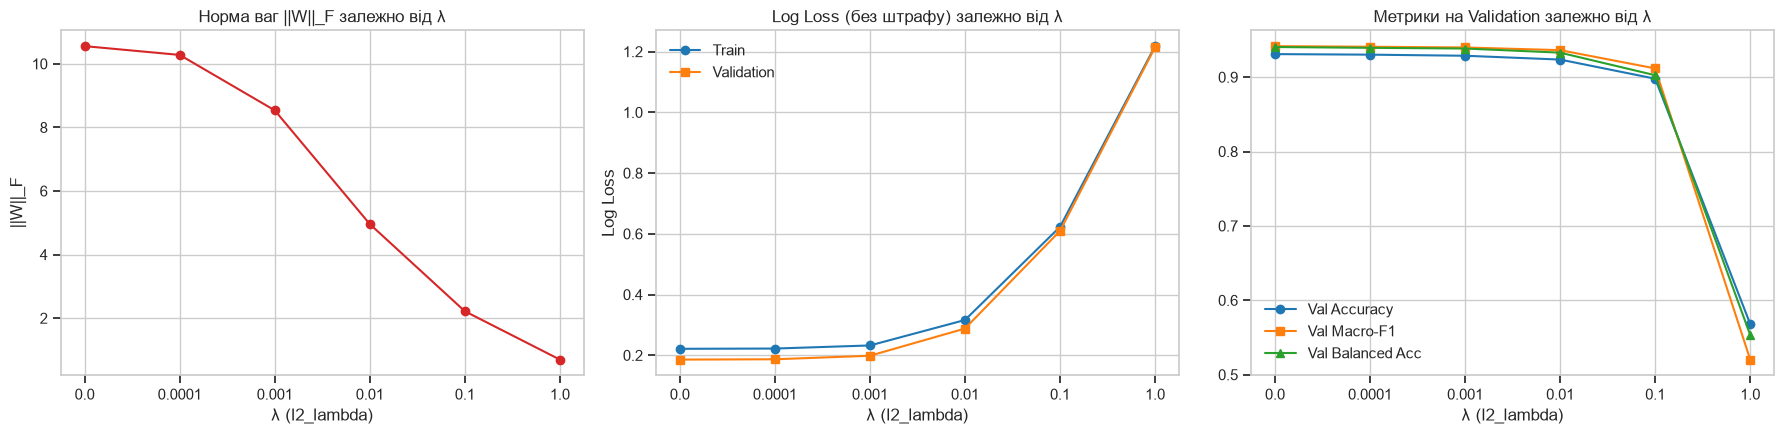

In [39]:
x_pos = np.arange(len(lambda_values))
x_lbl = [str(l) for l in lambda_values]

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

axes[0].plot(x_pos, ridge_df['W_norm (Frobenius)'], marker='o', color='tab:red')
axes[0].set_title('Норма ваг ||W||_F залежно від λ')
axes[0].set_ylabel('||W||_F')

axes[1].plot(x_pos, ridge_df['Train LogLoss'], marker='o', label='Train')
axes[1].plot(x_pos, ridge_df['Val LogLoss'], marker='s', label='Validation')
axes[1].set_title('Log Loss (без штрафу) залежно від λ')
axes[1].set_ylabel('Log Loss')
axes[1].legend()

axes[2].plot(x_pos, ridge_df['Val Acc'], marker='o', label='Val Accuracy')
axes[2].plot(x_pos, ridge_df['Val Macro-F1'], marker='s', label='Val Macro-F1')
axes[2].plot(x_pos, ridge_df['Val BalAcc'], marker='^', label='Val Balanced Acc')
axes[2].set_title('Метрики на Validation залежно від λ')
axes[2].legend()

for ax in axes:
    ax.set_xticks(x_pos)
    ax.set_xticklabels(x_lbl)
    ax.set_xlabel('λ (l2_lambda)')
plt.tight_layout()
plt.show()

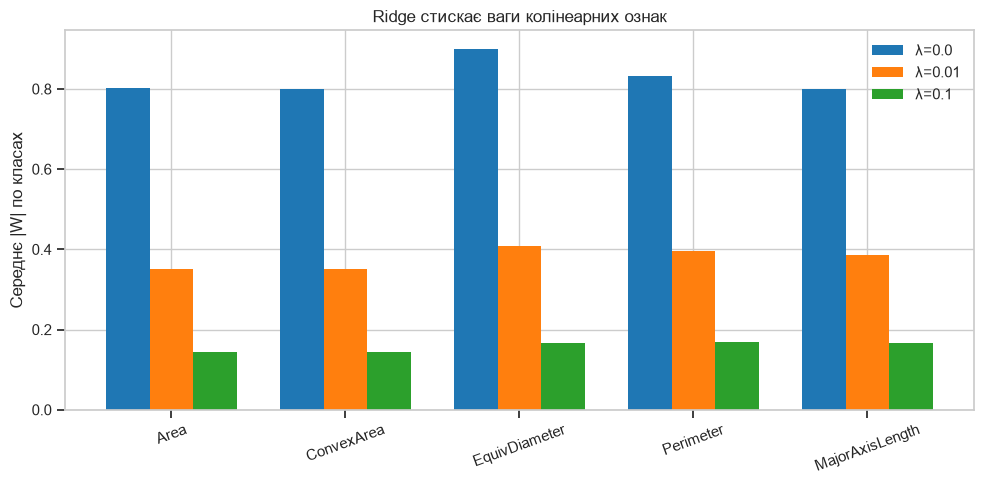

In [19]:
collinear_feats = ["Area", "ConvexArea", "EquivDiameter", "Perimeter", "MajorAxisLength"]
feat_idx = [FEATURE_COLUMNS.index(f) for f in collinear_feats]
lams_to_show = [0.0, 1e-2, 1e-1]

# середня абсолютна вага ознаки по всіх 7 класах
fig, ax = plt.subplots(figsize=(10, 5))
width = 0.25
for k, lam in enumerate(lams_to_show):
    vals = np.abs(ridge_models[lam].W[feat_idx, :]).mean(axis=1)
    ax.bar(np.arange(len(feat_idx)) + k * width, vals, width, label=f'λ={lam}')
ax.set_xticks(np.arange(len(feat_idx)) + width)
ax.set_xticklabels(collinear_feats, rotation=20)
ax.set_ylabel('Середнє |W| по класах')
ax.set_title('Ridge стискає ваги колінеарних ознак')
ax.legend()
plt.tight_layout()
plt.show()

Вплив λ при малій вибірці (n=300):
 lambda  W_norm (Frobenius)  Train LogLoss  Val LogLoss  Train Acc  Val Acc  Val Macro-F1  Gap (Train-Val Acc)
 0.0000              6.6932         0.2463       0.2545     0.9300   0.9199        0.9264               0.0101
 0.0001              6.6658         0.2469       0.2551     0.9300   0.9199        0.9264               0.0101
 0.0010              6.4305         0.2526       0.2602     0.9300   0.9199        0.9261               0.0101
 0.0100              4.8744         0.3111       0.3161     0.9267   0.9162        0.9233               0.0104
 0.1000              2.2128         0.6133       0.6190     0.8933   0.8802        0.8849               0.0131
 1.0000              0.6759         1.2186       1.2250     0.6533   0.6532        0.5876               0.0001


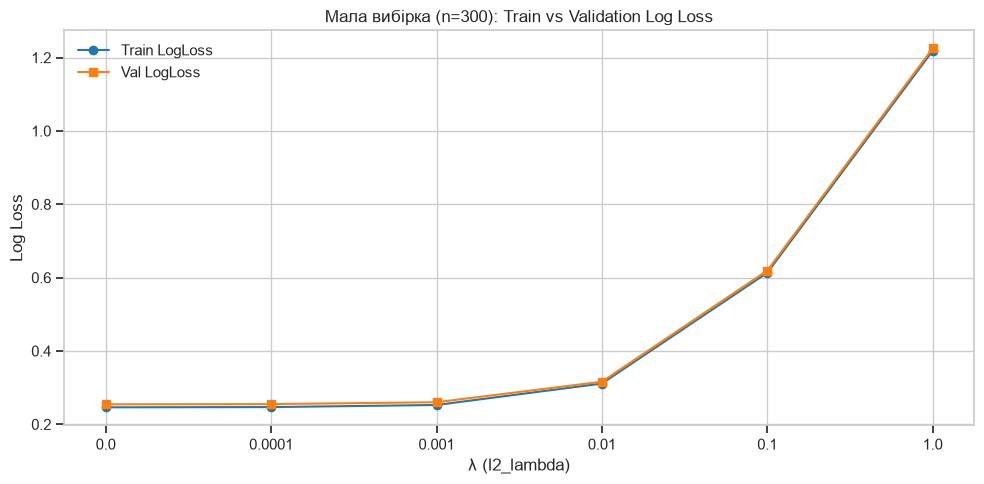

In [20]:
# Підвибірка FL Train Pool (лише train!), щоб змоделювати «малий клієнт»
rng_sub = np.random.RandomState(RANDOM_STATE)
sub_idx = rng_sub.choice(len(X_train_pool), size=300, replace=False)
X_small, Y_small = X_train_pool[sub_idx], Y_train_pool[sub_idx]

small_df, _ = run_ridge_sweep(X_small, Y_small, lambda_values, epochs=200)
small_df['Gap (Train-Val Acc)'] = small_df['Train Acc'] - small_df['Val Acc']
print("Вплив λ при малій вибірці (n=300):")
print(small_df[['lambda', 'W_norm (Frobenius)', 'Train LogLoss', 'Val LogLoss',
                'Train Acc', 'Val Acc', 'Val Macro-F1', 'Gap (Train-Val Acc)']]
      .round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x_pos, small_df['Train LogLoss'], marker='o', label='Train LogLoss')
ax.plot(x_pos, small_df['Val LogLoss'], marker='s', label='Val LogLoss')
ax.set_xticks(x_pos)
ax.set_xticklabels(x_lbl)
ax.set_xlabel('λ (l2_lambda)')
ax.set_ylabel('Log Loss')
ax.set_title('Мала вибірка (n=300): Train vs Validation Log Loss')
ax.legend()
plt.tight_layout()
plt.show()

### Інтерпретація впливу Ridge-регуляризації

**Норма ваг.** Зі збільшенням λ норма ваг ‖W‖_F монотонно спадає: з ≈10.5 (λ=0) до ≈8.5 (λ=0.001), ≈5.0 (λ=0.01), ≈2.2 (λ=0.1) і ≈0.7 (λ=1.0). Для λ ≤ 1e-4 різниця з нерегуляризованою моделлю майже непомітна, тож помітне стискання починається приблизно від λ=1e-3.

**Колінеарні ознаки.** Для Area, ConvexArea, EquivDiameter, Perimeter та MajorAxisLength середня |W| по класах без регуляризації становить ≈0.8–0.9, при λ=0.01 падає до ≈0.35–0.41, а при λ=0.1 — до ≈0.15–0.17. Тобто Ridge рівномірно стискає ваги всієї групи сильно корельованих ознак (r > 0.95), не дозволяючи їм набувати великих значень. Це пряме підтвердження твердження з EDA про стабілізуючу роль L2.

**Якість на Validation (повний FL Train Pool).** Для λ від 0 до 0.01 Accuracy, Macro-F1 та Balanced Accuracy майже не змінюються (≈0.93–0.94) і лише дуже повільно знижуються. При λ=0.1 спостерігається помітніше падіння, а при λ=1.0 — різкий обвал (Accuracy ≈0.57, Macro-F1 ≈0.52), що є типовим недонавчанням (underfitting): штраф настільки домінує над cross-entropy, що модель не здатна підігнатися до даних. Log Loss без штрафу зростає синхронно (≈0.19 при λ=0 → ≈1.2 при λ=1.0). Криві Train і Validation майже збігаються, тобто перенавчання на великій вибірці немає, і тому grid search обрав λ=0.0.

**Мала вибірка (n=300).** Навіть тут картина подібна: Val Accuracy 0.9199 при λ ≤ 1e-3, далі 0.9162 (λ=0.01), 0.8802 (λ=0.1) і 0.6532 (λ=1.0). Розрив Train–Val за Accuracy дуже малий (≈0.01) і при збільшенні λ не зменшується (при λ=0.1 навіть зростає до 0.013). Отже, у цьому експерименті Ridge **не** зменшив перенавчання і не покращив якість на Validation. Причина в тому, що лінійна softmax-модель із 16 стандартизованими ознаками має низьку ємність, і 300 прикладів достатньо, щоб вона не перенавчалась (200 епох також не призвели до помітного розриву).

**Висновок.** Ridge-регуляризація надійно виконує свою головну функцію: контролює величину ваг і стискає коефіцієнти колінеарних ознак. Водночас у цій задачі вона не дає виграшу в якості: найкращі метрики досягаються при λ=0 або дуже малих λ (≤ 1e-3), а надто великі значення (λ ≥ 0.1) призводять до недонавчання. Це узгоджується з вибором λ=0.0 у grid search. Практична цінність Ridge тут полягає в стабільності ваг, а не в підвищенні точності; вона могла б стати корисною для ще менших локальних вибірок або складніших моделей.

## Розділ 7: Розподіл даних між клієнтами та сервером

### Архітектура системи

- **Сервер (агрегатор)** має доступ лише до: Global Test, Global Validation, та параметрів 
  моделей (ваг), які повертають клієнти. Сервер **не має доступу** до сирих даних клієнтів.
- **Клієнти** мають доступ лише до власної локальної тренувальної вибірки $D_k$. Клієнт 
  **не має доступу** до Global Test, Global Validation, даних чи параметрів інших клієнтів 
  (лише до агрегованої глобальної моделі від сервера).

### Методика розподілу

FL Train Pool розподіляється між $K$ клієнтами так, що кожен приклад належить рівно одному 
клієнту. Досліджуємо два типи розподілу:

1. **IID** — кожен клієнт отримує стратифіковану частку даних, що зберігає глобальні 
   пропорції класів.
2. **Non-IID (Dirichlet)** — для кожного класу $c$ генеруються пропорції розподілу між 
   клієнтами $(p_{1c},...,p_{Kc}) \sim \text{Dirichlet}(\alpha,...,\alpha)$. Менше $\alpha$ 
   означає сильнішу неоднорідність (окремі клієнти можуть майже не мати певних класів).

Розподіл фіксується випадковим зерном (RANDOM_STATE) для відтворюваності.

IID-розподіл

In [21]:
def partition_iid(X, y, num_clients, random_state):
    """Стратифікований IID-розподіл: кожен клас ділиться порівну між клієнтами."""
    rng = np.random.RandomState(random_state)
    client_dict = {i: [] for i in range(num_clients)}

    for cls in np.unique(y):
        idx = np.where(y == cls)[0]
        rng.shuffle(idx)
        split_idx = np.array_split(idx, num_clients)
        for i, client_idx in enumerate(split_idx):
            client_dict[i].extend(client_idx.tolist())

    out = {}
    for i in range(num_clients):
        idx = np.array(sorted(client_dict[i]), dtype=np.int64)
        out[i] = {'X': X[idx], 'y': y[idx], 'indices': idx}

    # Перевірка: кожен приклад належить рівно одному клієнту
    flat = np.concatenate([out[i]['indices'] for i in range(num_clients)])
    assert len(np.unique(flat)) == len(y), "Кожен приклад має належати рівно одному клієнту."
    return out

Dirichlet Non-IID розподіл

In [22]:
def partition_dirichlet(X, y, num_clients, alpha, random_state):
    """
    Non-IID розподіл через Dirichlet-розподіл: для кожного класу генеруються
    пропорції розподілу прикладів цього класу між клієнтами.
    """
    rng = np.random.RandomState(random_state)
    client_indices = {i: [] for i in range(num_clients)}
    classes = np.unique(y)

    for cls in classes:
        class_idx = np.where(y == cls)[0]
        rng.shuffle(class_idx)

        proportions = rng.dirichlet(alpha * np.ones(num_clients))
        counts = np.floor(proportions * len(class_idx)).astype(int)

        # Розподіляємо залишок (через округлення) клієнтам з найбільшою пропорцією
        remainder = len(class_idx) - counts.sum()
        if remainder > 0:
            extra = np.argsort(proportions)[::-1][:remainder]
            counts[extra] += 1

        for client_id, count in enumerate(counts):
            selected = class_idx[:count]
            class_idx = class_idx[count:]
            client_indices[client_id].extend(selected.tolist())

    # Захист від абсолютно порожніх/надто малих клієнтів (потрібно для стабільності батчів)
    min_required = max(1, 64 // max(1, num_clients))
    while min(len(v) for v in client_indices.values()) < min_required:
        donor = max(client_indices, key=lambda k: len(client_indices[k]))
        recipient = min(client_indices, key=lambda k: len(client_indices[k]))
        if len(client_indices[donor]) <= 1:
            break
        client_indices[recipient].append(client_indices[donor].pop())

    out = {}
    for i in range(num_clients):
        idx = np.array(sorted(client_indices[i]), dtype=np.int64)
        out[i] = {'X': X[idx], 'y': y[idx], 'indices': idx}

    flat = np.concatenate([out[i]['indices'] for i in range(num_clients)])
    assert len(np.unique(flat)) == len(y), "Кожен приклад має належати рівно одному клієнту."
    assert len(flat) == len(y), "Розмір розподілу не відповідає FL Train Pool."
    return out

Візуалізація розподілу класів між клієнтами

In [23]:
def visualize_client_distributions(client_dict, title):
    num_clients = len(client_dict)
    class_names = list(class_to_id.keys())
    class_counts = np.zeros((num_clients, len(class_names)), dtype=int)

    for cid, client in client_dict.items():
        for cls_name in class_names:
            class_counts[cid, class_to_id[cls_name]] = np.sum(client['y'] == cls_name)

    fig, ax = plt.subplots(figsize=(12, 6))
    x = np.arange(num_clients)
    bottom = np.zeros(num_clients)

    for j, cls_name in enumerate(class_names):
        values = class_counts[:, j]
        ax.bar(x, values, bottom=bottom, alpha=0.85, label=cls_name)
        bottom += values

    ax.set_xticks(x)
    ax.set_xticklabels([f'Клієнт {i}' for i in range(num_clients)])
    ax.set_xlabel('Клієнт')
    ax.set_ylabel('Кількість прикладів')
    ax.set_title(title)
    ax.legend(loc='upper left', bbox_to_anchor=(1.0, 1.0))
    plt.tight_layout()
    plt.show()

    # Таблиця з кількістю прикладів на клієнта (для документування розподілу)
    counts_per_client = pd.Series(
        {f'Клієнт {i}': len(client_dict[i]['y']) for i in range(num_clients)}
    )
    print("Кількість прикладів на клієнта:")
    print(counts_per_client)

    too_small = counts_per_client[counts_per_client < 10]
    if len(too_small) > 0:
        print(f"\n⚠️ УВАГА: клієнти з < 10 прикладами: {list(too_small.index)}")
    else:
        print("\n✓ Усі клієнти мають достатню кількість прикладів (≥ 10).")

    return class_counts

Демонстрація: порівняння IID vs сильний Non-IID

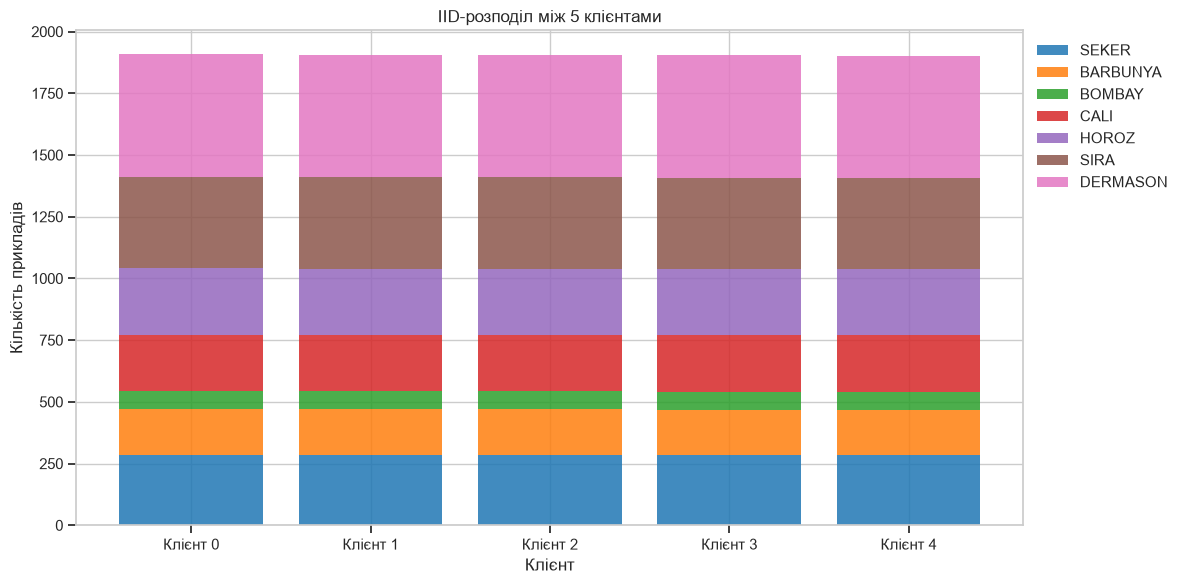

Кількість прикладів на клієнта:
Клієнт 0    1909
Клієнт 1    1906
Клієнт 2    1905
Клієнт 3    1904
Клієнт 4    1903
dtype: int64

✓ Усі клієнти мають достатню кількість прикладів (≥ 10).


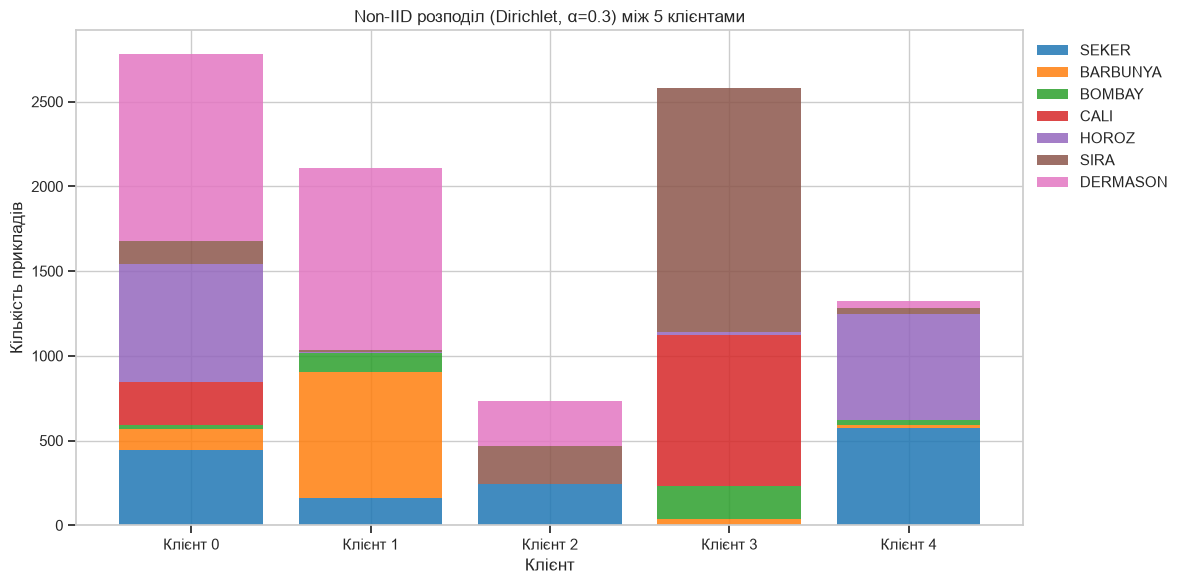

Кількість прикладів на клієнта:
Клієнт 0    2781
Клієнт 1    2108
Клієнт 2     735
Клієнт 3    2582
Клієнт 4    1321
dtype: int64

✓ Усі клієнти мають достатню кількість прикладів (≥ 10).


array([[ 443,  127,   24,  250,  697,  137, 1103],
       [ 158,  745,  113,    2,    7,   10, 1073],
       [ 243,    1,    0,    0,    0,  225,  266],
       [   0,   37,  197,  888,   21, 1437,    2],
       [ 574,   15,   32,    1,  624,   37,   38]])

In [24]:
K_demo = 5

iid_demo = partition_iid(X_train_pool, y_train_pool, num_clients=K_demo, random_state=RANDOM_STATE)
visualize_client_distributions(iid_demo, f'IID-розподіл між {K_demo} клієнтами')

dirichlet_demo = partition_dirichlet(X_train_pool, y_train_pool, num_clients=K_demo,
                                      alpha=0.3, random_state=RANDOM_STATE)
visualize_client_distributions(dirichlet_demo, f'Non-IID розподіл (Dirichlet, α=0.3) між {K_demo} клієнтами')

### Висновок

**IID-розподіл.** Усі 5 клієнтів отримали практично однакову загальну кількість прикладів 
(~1900–1910 кожен), і, що найважливіше, пропорції кожного класу всередині кожного клієнта 
візуально ідентичні (наприклад, частка DERMASON, SIRA, HOROZ виглядає однаково на всіх 
п'яти стовпчиках). Це підтверджує, що стратифікований поклассовий розподіл спрацював 
коректно: кожен клієнт має статистично репрезентативну "мініатюрну копію" глобального 
розподілу даних.

**Non-IID розподіл (α=0.3).** Картина кардинально відрізняється. Загальна кількість 
прикладів на клієнта суттєво нерівномірна — від ~730 (Клієнт 2) до ~2790 (Клієнт 0), 
тобто різниця майже у 4 рази. Ще важливіше — розподіл класів усередині кожного клієнта 
вкрай зміщений: наприклад, Клієнт 1 майже повністю складається з BARBUNYA та DERMASON 
(і практично не має CALI чи HOROZ), Клієнт 3 домінується SIRA та CALI, а Клієнт 4 — SEKER 
та HOROZ. Жоден клієнт не має даних, репрезентативних для повного набору з 7 класів. 
Перевірка на клієнтів з < 10 прикладами (вбудована в код) не виявила проблемних клієнтів, 
однак окремі класи в окремих клієнтів представлені лише кількома десятками прикладів або 
відсутні майже повністю (наприклад, BOMBAY у Клієнта 1 та Клієнта 4).

**Вплив на якість глобальної моделі.** Такий сильний перекіс класів (α=0.3) означає, що 
кожен клієнт локально оптимізує модель під дуже вузьке, зміщене підмножина класів — по 
суті, локальна модель кожного клієнта "спеціалізується" лише на 2–3 класах замість усіх 7. 
Локальні градієнти різних клієнтів вказуватимуть у суттєво різних напрямках у просторі 
параметрів W, оскільки кожен клієнт "тягне" модель у бік своїх домінуючих класів. 
Усереднення (FedAvg) таких різноспрямованих оновлень дає менш точну апроксимацію справжнього 
глобального градієнта, ніж при IID-розподілі, що потенційно уповільнює збіжність та/або 
погіршує фінальну якість глобальної моделі — це кількісно перевіряється в Експерименті 1 
(розділ 10).

## Розділ 8: Агрегація FedAvg та локальне навчання

### Алгоритм FedAvg

1. Сервер ініціалізує глобальну модель $w^0$.
2. На кожному раунді $t$ сервер передає поточну глобальну модель $w^t$ обраним клієнтам.
3. Кожен клієнт $k$ навчає локальну модель протягом $E$ локальних епох, починаючи з $w^t$.
4. Клієнт повертає оновлені параметри $w^{t+1}_k$ серверу.
5. Сервер агрегує параметри зваженим середнім за кількістю прикладів:

$$w^{t+1} = \sum_{k \in S_t} \frac{n_k}{\sum_{j \in S_t} n_j} \, w^{t+1}_k$$

6. Глобальна модель оцінюється на Global Validation.

### Чому зважування за кількістю прикладів?

Клієнти з більшою кількістю тренувальних прикладів дають статистично надійніші (менш 
шумні) оцінки локального градієнта — їхні локальні мінімуми ближчі до справжнього 
емпіричного ризику на повному розподілі даних. Зважування пропорційно до $n_k$ 
математично апроксимує мінімізацію глобальної функції втрат так, ніби модель навчалась 
централізовано на об'єднанні всіх локальних вибірок.

**Якщо використати просте (незважене) середнє** — усі клієнти отримають однаковий вплив 
на глобальну модель незалежно від розміру їхніх даних. Це означає, що клієнт із 50 
прикладами матиме такий самий вплив, як клієнт із 5000 прикладів, що спотворює глобальну 
модель у бік малих, статистично ненадійних клієнтів і відходить від справжньої мети — 
мінімізації втрат на об'єднаному розподілі даних.

FedAvg-агрегація

In [25]:
def fedavg(local_weights_list, local_sample_counts):
    """
    Зважена агрегація параметрів клієнтів за методом FedAvg.
    local_weights_list: список кортежів (W_k, b_k) для кожного клієнта.
    local_sample_counts: список n_k - кількість прикладів у кожного клієнта.
    """
    total = np.sum(local_sample_counts)
    if total == 0:
        raise ValueError("FedAvg отримав нульову загальну кількість прикладів.")

    W_global = np.zeros_like(local_weights_list[0][0], dtype=np.float64)
    b_global = np.zeros_like(local_weights_list[0][1], dtype=np.float64)

    for (W_local, b_local), n_k in zip(local_weights_list, local_sample_counts):
        weight = n_k / total
        W_global += weight * W_local
        b_global += weight * b_local

    return W_global, b_global

Локальне навчання клієнта

In [26]:
def train_local_client(client_X, client_Y, global_W, global_b,
                        local_epochs, lr, batch_size, l2_lambda):
    """
    Клієнт отримує поточні глобальні параметри, донавчає локальну модель
    протягом local_epochs епох на власних даних, повертає оновлені параметри.
    """
    model = SoftmaxLogisticRegression(
        learning_rate=lr, epochs=local_epochs, batch_size=batch_size,
        l2_lambda=l2_lambda, random_state=RANDOM_STATE,
    )
    model.set_params(global_W, global_b)          # старт з глобальних ваг
    model.fit(client_X, client_Y, init_weights=False)   # не переініціалізовувати ваги!
    return model.W, model.b, client_X.shape[0]

Основний цикл федеративного навчання

In [27]:
def federated_train(client_dict, X_val, y_val, Y_val, num_rounds,
                     local_epochs, lr, batch_size, l2_lambda, verbose=True):
    """
    Повний цикл симуляції FedAvg: num_rounds раундів комунікації,
    на кожному раунді всі клієнти навчаються локально, сервер агрегує ваги.
    """
    num_classes = Y_val.shape[1]
    W_global = np.zeros((X_val.shape[1], num_classes), dtype=np.float64)
    b_global = np.zeros((1, num_classes), dtype=np.float64)

    history = []

    for r in range(num_rounds):
        local_weights = []
        local_counts = []

        # Цикл по клієнтах (дозволений завданням)
        for cid in sorted(client_dict.keys()):
            client = client_dict[cid]
            client_X = client['X']

            client_Y = np.zeros((len(client['y']), num_classes), dtype=np.float64)
            for j, label in enumerate(client['y']):
                client_Y[j, class_to_id[label]] = 1.0

            W_local, b_local, n_k = train_local_client(
                client_X, client_Y, W_global, b_global,
                local_epochs, lr, batch_size, l2_lambda
            )
            local_weights.append((W_local, b_local))
            local_counts.append(n_k)

        # Агрегація на сервері
        W_global, b_global = fedavg(local_weights, local_counts)

        # Оцінка глобальної моделі на Global Validation (сервер має до нього доступ)
        temp_model = SoftmaxLogisticRegression(
            learning_rate=lr, epochs=1, batch_size=batch_size,
            l2_lambda=l2_lambda, random_state=RANDOM_STATE
        )
        temp_model.set_params(W_global, b_global)

        val_proba = temp_model.predict_proba(X_val)
        val_pred = np.argmax(val_proba, axis=1)
        val_true = np.argmax(Y_val, axis=1)

        val_acc = accuracy_score(val_true, val_pred)
        val_loss = -np.mean(np.sum(Y_val * np.log(val_proba + 1e-12), axis=1))
        val_macro_f1 = f1_score(val_true, val_pred, average='macro')

        history.append({
            'round': r + 1, 'val_loss': val_loss,
            'val_accuracy': val_acc, 'val_macro_f1': val_macro_f1
        })

        if verbose:
            print(f"Раунд {r + 1:02d}: val_loss={val_loss:.4f}, "
                  f"val_acc={val_acc:.4f}, val_macro_f1={val_macro_f1:.4f}")

    return W_global, b_global, history

Швидка перевірка: один прогін FedAvg

In [28]:
# Швидкий тест: 5 клієнтів, помірна неоднорідність, 10 раундів
quick_test_dict = partition_dirichlet(X_train_pool, y_train_pool, num_clients=5,
                                       alpha=1.0, random_state=RANDOM_STATE)

W_test, b_test, test_history = federated_train(
    quick_test_dict, X_val, y_val, Y_val,
    num_rounds=10, local_epochs=5, lr=0.1, batch_size=64, l2_lambda=0.001
)

print("\n✓ FedAvg відпрацював без помилок.")
print(f"Фінальна validation accuracy: {test_history[-1]['val_accuracy']:.4f}")

Раунд 01: val_loss=0.5200, val_acc=0.8780, val_macro_f1=0.8919
Раунд 02: val_loss=0.3832, val_acc=0.9133, val_macro_f1=0.9252
Раунд 03: val_loss=0.3264, val_acc=0.9192, val_macro_f1=0.9314
Раунд 04: val_loss=0.2954, val_acc=0.9206, val_macro_f1=0.9322
Раунд 05: val_loss=0.2760, val_acc=0.9206, val_macro_f1=0.9329
Раунд 06: val_loss=0.2627, val_acc=0.9236, val_macro_f1=0.9357
Раунд 07: val_loss=0.2530, val_acc=0.9251, val_macro_f1=0.9371
Раунд 08: val_loss=0.2457, val_acc=0.9258, val_macro_f1=0.9376
Раунд 09: val_loss=0.2400, val_acc=0.9265, val_macro_f1=0.9386
Раунд 10: val_loss=0.2354, val_acc=0.9273, val_macro_f1=0.9391

✓ FedAvg відпрацював без помилок.
Фінальна validation accuracy: 0.9273


## Розділ 9: Дослідження ефектів федеративного навчання

## Експеримент 1: Вплив неоднорідності даних (Dirichlet α)

Порівнюємо якість глобальної моделі при трьох рівнях неоднорідності:
- **α = 5.0** — близько до IID
- **α = 1.0** — помірна неоднорідність
- **α = 0.3** — сильна неоднорідність

Параметри федеративного навчання фіксовані (K=5 клієнтів, 20 раундів, E=5 локальних епох), 
щоб ізолювати вплив саме параметра α.

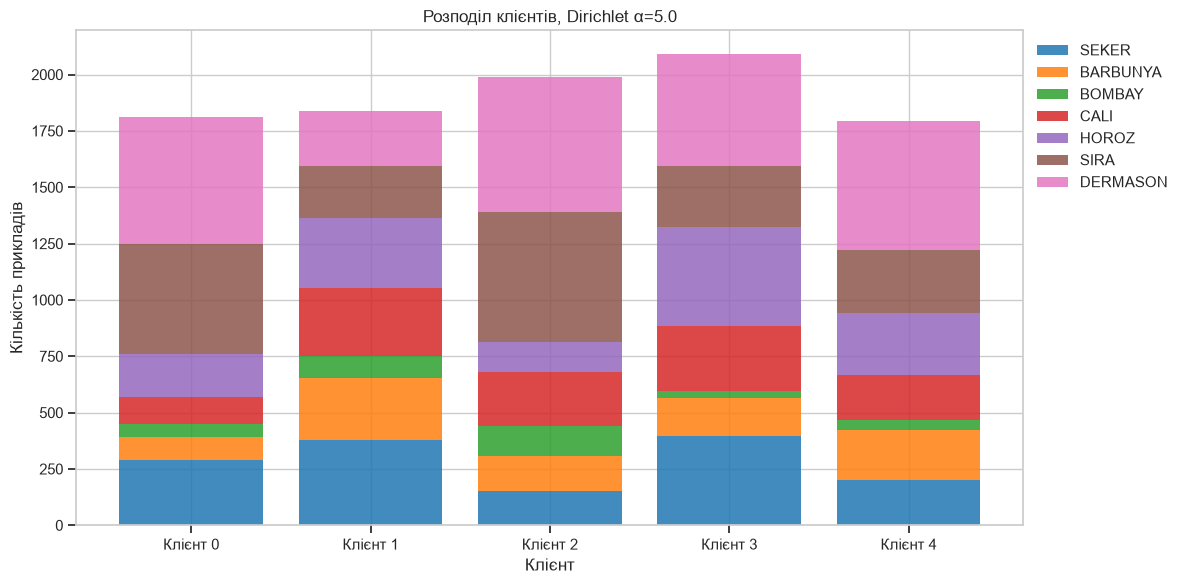

Кількість прикладів на клієнта:
Клієнт 0    1811
Клієнт 1    1840
Клієнт 2    1989
Клієнт 3    2091
Клієнт 4    1796
dtype: int64

✓ Усі клієнти мають достатню кількість прикладів (≥ 10).

--- Навчання при α=5.0 ---
Раунд 01: val_loss=0.4716, val_acc=0.9001, val_macro_f1=0.9089
Раунд 02: val_loss=0.3546, val_acc=0.9184, val_macro_f1=0.9268
Раунд 03: val_loss=0.3062, val_acc=0.9206, val_macro_f1=0.9313
Раунд 04: val_loss=0.2796, val_acc=0.9229, val_macro_f1=0.9350
Раунд 05: val_loss=0.2629, val_acc=0.9214, val_macro_f1=0.9339
Раунд 06: val_loss=0.2513, val_acc=0.9251, val_macro_f1=0.9363
Раунд 07: val_loss=0.2429, val_acc=0.9265, val_macro_f1=0.9374
Раунд 08: val_loss=0.2365, val_acc=0.9273, val_macro_f1=0.9382
Раунд 09: val_loss=0.2314, val_acc=0.9265, val_macro_f1=0.9377
Раунд 10: val_loss=0.2274, val_acc=0.9265, val_macro_f1=0.9373
Раунд 11: val_loss=0.2240, val_acc=0.9265, val_macro_f1=0.9373
Раунд 12: val_loss=0.2213, val_acc=0.9273, val_macro_f1=0.9378
Раунд 13: val_loss=0.2189, v

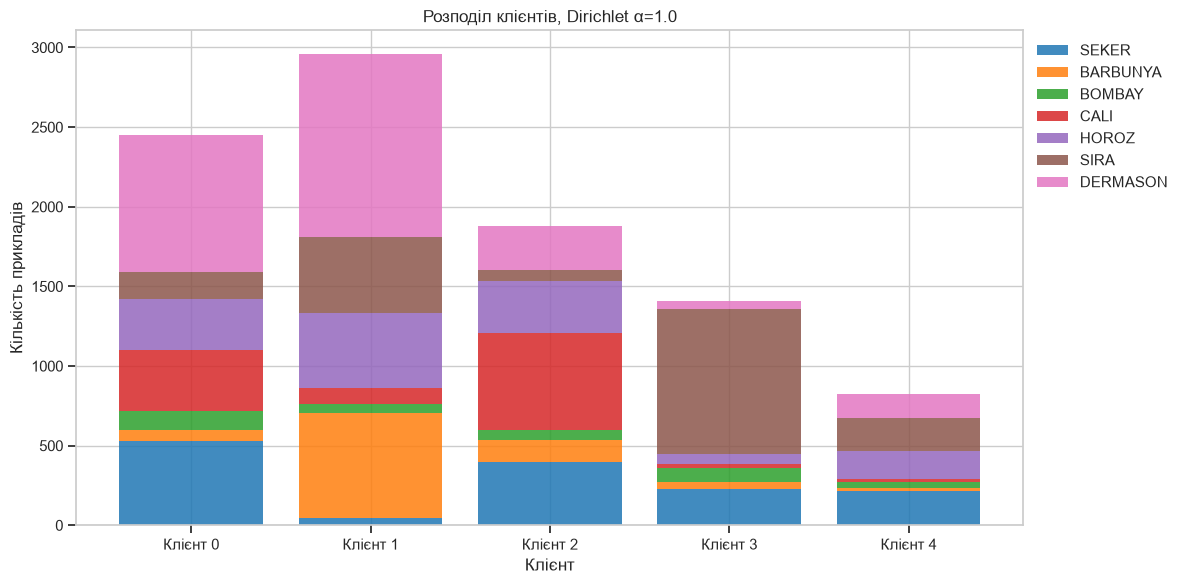

Кількість прикладів на клієнта:
Клієнт 0    2449
Клієнт 1    2959
Клієнт 2    1882
Клієнт 3    1411
Клієнт 4     826
dtype: int64

✓ Усі клієнти мають достатню кількість прикладів (≥ 10).

--- Навчання при α=1.0 ---
Раунд 01: val_loss=0.5200, val_acc=0.8780, val_macro_f1=0.8919
Раунд 02: val_loss=0.3832, val_acc=0.9133, val_macro_f1=0.9252
Раунд 03: val_loss=0.3264, val_acc=0.9192, val_macro_f1=0.9314
Раунд 04: val_loss=0.2954, val_acc=0.9206, val_macro_f1=0.9322
Раунд 05: val_loss=0.2760, val_acc=0.9206, val_macro_f1=0.9329
Раунд 06: val_loss=0.2627, val_acc=0.9236, val_macro_f1=0.9357
Раунд 07: val_loss=0.2530, val_acc=0.9251, val_macro_f1=0.9371
Раунд 08: val_loss=0.2457, val_acc=0.9258, val_macro_f1=0.9376
Раунд 09: val_loss=0.2400, val_acc=0.9265, val_macro_f1=0.9386
Раунд 10: val_loss=0.2354, val_acc=0.9273, val_macro_f1=0.9391
Раунд 11: val_loss=0.2317, val_acc=0.9273, val_macro_f1=0.9391
Раунд 12: val_loss=0.2286, val_acc=0.9273, val_macro_f1=0.9384
Раунд 13: val_loss=0.2260, v

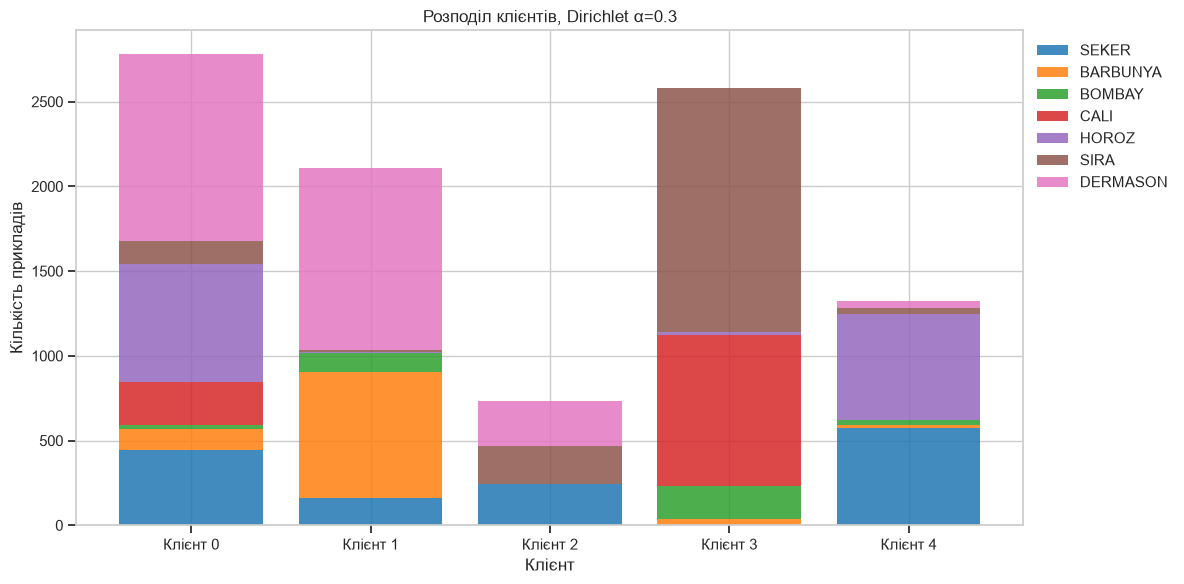

Кількість прикладів на клієнта:
Клієнт 0    2781
Клієнт 1    2108
Клієнт 2     735
Клієнт 3    2582
Клієнт 4    1321
dtype: int64

✓ Усі клієнти мають достатню кількість прикладів (≥ 10).

--- Навчання при α=0.3 ---
Раунд 01: val_loss=0.6405, val_acc=0.9082, val_macro_f1=0.9088
Раунд 02: val_loss=0.4640, val_acc=0.9140, val_macro_f1=0.9291
Раунд 03: val_loss=0.3865, val_acc=0.9155, val_macro_f1=0.9302
Раунд 04: val_loss=0.3430, val_acc=0.9199, val_macro_f1=0.9335
Раунд 05: val_loss=0.3154, val_acc=0.9229, val_macro_f1=0.9361
Раунд 06: val_loss=0.2964, val_acc=0.9243, val_macro_f1=0.9367
Раунд 07: val_loss=0.2826, val_acc=0.9243, val_macro_f1=0.9367
Раунд 08: val_loss=0.2721, val_acc=0.9251, val_macro_f1=0.9385
Раунд 09: val_loss=0.2639, val_acc=0.9243, val_macro_f1=0.9377
Раунд 10: val_loss=0.2574, val_acc=0.9251, val_macro_f1=0.9385
Раунд 11: val_loss=0.2520, val_acc=0.9258, val_macro_f1=0.9390
Раунд 12: val_loss=0.2476, val_acc=0.9273, val_macro_f1=0.9402
Раунд 13: val_loss=0.2438, v

In [29]:
alpha_values = [5.0, 1.0, 0.3]
K = 5
num_rounds = 20
local_epochs = 5
lr = 0.1
batch_size = 64
l2_lambda = 0.001

exp1_results = []
exp1_histories = {}

for alpha in alpha_values:
    client_dict = partition_dirichlet(X_train_pool, y_train_pool, num_clients=K,
                                       alpha=alpha, random_state=RANDOM_STATE)
    visualize_client_distributions(client_dict, f'Розподіл клієнтів, Dirichlet α={alpha}')

    print(f"\n--- Навчання при α={alpha} ---")
    W_global, b_global, history = federated_train(
        client_dict, X_val, y_val, Y_val,
        num_rounds=num_rounds, local_epochs=local_epochs,
        lr=lr, batch_size=batch_size, l2_lambda=l2_lambda,
    )
    exp1_histories[alpha] = history

    model = SoftmaxLogisticRegression(learning_rate=lr, epochs=1, batch_size=batch_size,
                                       l2_lambda=l2_lambda, random_state=RANDOM_STATE)
    model.set_params(W_global, b_global)
    metrics = evaluate_model(model, X_test, y_test_int, id_to_class)

    exp1_results.append({
        'Alpha': alpha,
        'Accuracy': metrics['Accuracy'],
        'Macro-F1': metrics['Macro-F1'],
        'Balanced Accuracy': metrics['Balanced Accuracy'],
        'Log Loss': metrics['Log Loss'],
    })

Графіки збіжності

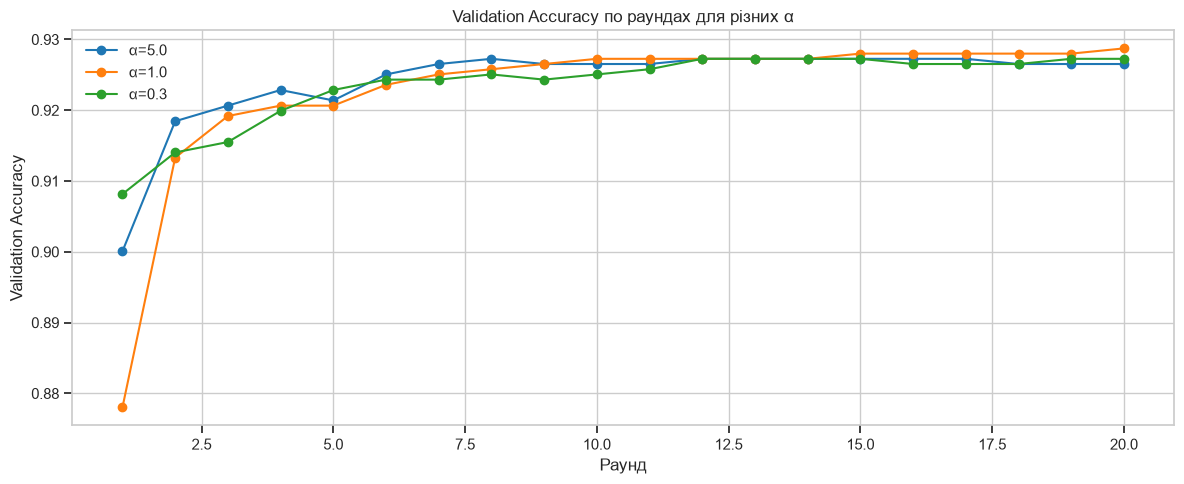

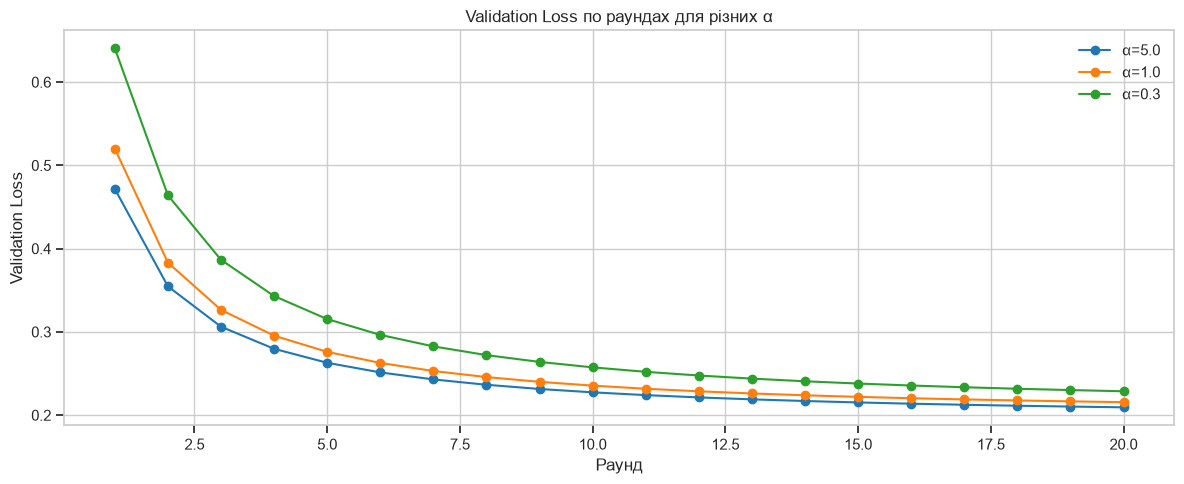

In [30]:
plt.figure(figsize=(12, 5))
for alpha in alpha_values:
    rounds = [entry['round'] for entry in exp1_histories[alpha]]
    vals = [entry['val_accuracy'] for entry in exp1_histories[alpha]]
    plt.plot(rounds, vals, marker='o', label=f'α={alpha}')
plt.title('Validation Accuracy по раундах для різних α')
plt.xlabel('Раунд')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
for alpha in alpha_values:
    rounds = [entry['round'] for entry in exp1_histories[alpha]]
    vals = [entry['val_loss'] for entry in exp1_histories[alpha]]
    plt.plot(rounds, vals, marker='o', label=f'α={alpha}')
plt.title('Validation Loss по раундах для різних α')
plt.xlabel('Раунд')
plt.ylabel('Validation Loss')
plt.legend()
plt.tight_layout()
plt.show()

Графік залежності фінальної якості від α + підсумкова таблиця

Підсумок Експерименту 1:
 Alpha  Accuracy  Macro-F1  Balanced Accuracy  Log Loss
   5.0    0.9181    0.9301             0.9275    0.2399
   1.0    0.9177    0.9298             0.9271    0.2444
   0.3    0.9166    0.9298             0.9280    0.2593


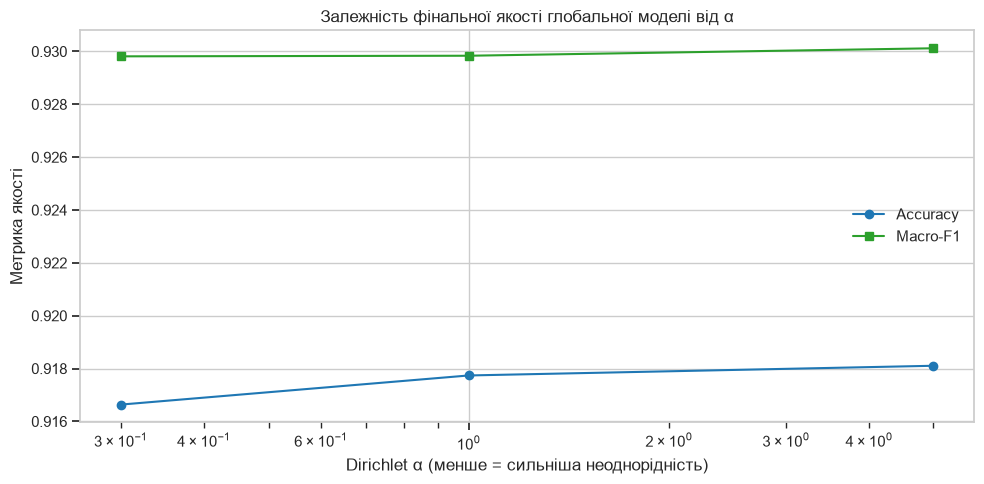

In [31]:
exp1_df = pd.DataFrame(exp1_results)
print("Підсумок Експерименту 1:")
print(exp1_df.round(4).to_string(index=False))

# Графік залежності фінальної якості (на Global Test) від α
fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(exp1_df['Alpha'], exp1_df['Accuracy'], marker='o', color='tab:blue', label='Accuracy')
ax1.plot(exp1_df['Alpha'], exp1_df['Macro-F1'], marker='s', color='tab:green', label='Macro-F1')
ax1.set_xlabel('Dirichlet α (менше = сильніша неоднорідність)')
ax1.set_ylabel('Метрика якості')
ax1.set_title('Залежність фінальної якості глобальної моделі від α')
ax1.legend()
ax1.set_xscale('log')  # логарифмічна шкала, бо α змінюється в широкому діапазоні
plt.tight_layout()
plt.show()

### Висновок

**Динаміка збіжності.** На графіку Validation Loss чітко видно очікуваний ефект: при 
сильнішій неоднорідності (α=0.3) початковий loss найвищий (0.64 на 1-му раунді проти 0.47 
при α=5.0) і крива спадає повільніше протягом усіх 20 раундів — навіть на 20-му раунді 
loss для α=0.3 (0.229) залишається помітно вищим за α=5.0 (0.209). На графіку Validation 
Accuracy ефект найпомітніший на перших 2–3 раундах (α=5.0 стартує з 90.0%, тоді як α=1.0 — 
лише з 87.8%), проте вже після ~10-го раунду криві практично зливаються.

**Фінальна якість vs α.** На Global Test: Accuracy становить 0.9181 (α=5.0), 0.9177 (α=1.0), 
0.9166 (α=0.3) — монотонне, але дуже незначне падіння (~0.15 в.п.) зі зростанням 
неоднорідності. Macro-F1 та Balanced Accuracy взагалі майже не змінюються (0.9301→0.9298), 
Log Loss зростає трохи помітніше: з 0.2399 (α=5.0) до 0.2593 (α=0.3).

Такий слабкий ефект пояснюється двома факторами. По-перше, softmax-регресія — опукла 
модель з єдиним глобальним мінімумом; на відміну від глибоких нейромереж, де client drift 
може "розкидати" локальні моделі по різних локальних мінімумах нелінійного ландшафту, тут 
усі клієнти врешті тягнуть ваги в напрямку одного й того самого оптимуму, лише з різною 
швидкістю збіжності. По-друге, 20 комунікаційних раундів виявляється достатньо, щоб 
практично нівелювати початкову різницю в швидкості збіжності — якби раундів було менше 
(наприклад, 5), різниця у фінальній якості була б значно суттєвішою.

**Чому Non-IID дані можуть погіршувати федеративне навчання?**
Коли дані сильно неоднорідні, кожен клієнт локально оптимізує модель під власний, зміщений 
розподіл класів (див. розділ 7: при α=0.3 окремі клієнти майже не мають певних класів). 
Локальні градієнти різних клієнтів вказують у різних напрямках у просторі параметрів — 
кожен клієнт "тягне" ваги в бік своїх домінуючих класів. Усереднення (FedAvg) таких 
різноспрямованих оновлень дає менш точну апроксимацію справжнього глобального градієнта, 
ніж при IID-розподілі. У нашому експерименті це проявилось передусім як **уповільнення 
збіжності** (вищий loss на ранніх раундах), а не як суттєве погіршення фінальної якості — 
через лінійну природу моделі, описану вище.

**Чи може глобальна модель бути гіршою за централізовану?**
Так, теоретично може, і в нашому випадку це частково підтвердилось: централізована модель 
на Test дала Accuracy=0.9196, тоді як федеративна (α=0.3) — 0.9166, тобто трохи нижче. 
Централізована модель безпосередньо мінімізує втрати на об'єднаних даних єдиним 
узгодженим градієнтним спуском, тоді як федеративна модель — це усереднення кількох 
окремо оптимізованих локальних моделей, що є лише наближенням до централізованого 
рішення. Різниця невелика (~0.3 в.п.), що узгоджується з відносною стійкістю лінійних 
моделей до федеративної агрегації.

**Чи може глобальна модель бути гіршою за деякі локальні моделі?**
На Global Test — ні, оскільки локальні моделі окремих клієнтів "бачать" лише вузьку 
підмножину класів (особливо при α=0.3) і погано узагальнюють на класи, відсутні в їхніх 
локальних даних (це буде кількісно показано в порівняльній таблиці Local vs Global vs 
Centralized, розділ 12). Однак на **власному локальному тестовому наборі** клієнта 
(де розподіл збігається з його тренувальними даними) локальна модель цілком могла б 
перевершити глобальну — це залишається поза межами обов'язкових експериментів цієї 
роботи.

## Експеримент 2: Вплив кількості локальних епох (Client Drift)

Фіксуємо розподіл клієнтів (α=1.0, помірна неоднорідність, K=5) і варіюємо кількість 
локальних епох $E$: 1, 5, 10. Мета — дослідити компроміс "комунікація vs обчислення" та 
явище **client drift**.

### Що таке client drift?

Client drift — це надмірне відхилення локальної моделі клієнта від поточної глобальної 
моделі $w^t$ у процесі кількох локальних епох навчання. Що більше локальних епох $E$ 
виконує клієнт, перш ніж повернути оновлені ваги серверу, то далі локальна модель 
"заходить" у напрямку локального (зміщеного) оптимуму клієнта — особливо в Non-IID 
сценарії, де цей локальний оптимум може суттєво відрізнятись від глобального.

Це створює компроміс:
- **Більше E** → менше раундів комунікації потрібно для збіжності (ефективніше з точки 
  зору мережевого трафіку), але **сильніший client drift** — локальні оновлення можуть 
  "тягнути" в різні боки, і після агрегації сервер отримує суперечливе, зашумлене 
  усереднення.
- **Менше E** (наприклад, E=1) → менший client drift на кожному раунді, ближче до 
  "справжнього" federated SGD, але потрібно більше раундів комунікації для тієї ж якості.

In [32]:
alpha = 1.0
K = 5
num_rounds = 20
lr = 0.1
batch_size = 64
l2_lambda = 0.001
local_epoch_values = [1, 5, 10]

exp2_results = []
exp2_histories = {}

for E in local_epoch_values:
    # Той самий розподіл клієнтів для всіх E (щоб ізолювати вплив саме E)
    client_dict = partition_dirichlet(X_train_pool, y_train_pool, num_clients=K,
                                       alpha=alpha, random_state=RANDOM_STATE)

    print(f"\n--- Навчання з локальними епохами E={E} ---")
    W_global, b_global, history = federated_train(
        client_dict, X_val, y_val, Y_val,
        num_rounds=num_rounds, local_epochs=E,
        lr=lr, batch_size=batch_size, l2_lambda=l2_lambda,
    )
    exp2_histories[E] = history

    model = SoftmaxLogisticRegression(learning_rate=lr, epochs=1, batch_size=batch_size,
                                       l2_lambda=l2_lambda, random_state=RANDOM_STATE)
    model.set_params(W_global, b_global)
    metrics = evaluate_model(model, X_test, y_test_int, id_to_class)

    exp2_results.append({
        'Local Epochs': E,
        'Accuracy': metrics['Accuracy'],
        'Macro-F1': metrics['Macro-F1'],
        'Balanced Accuracy': metrics['Balanced Accuracy'],
        'Log Loss': metrics['Log Loss'],
    })


--- Навчання з локальними епохами E=1 ---
Раунд 01: val_loss=0.8842, val_acc=0.7480, val_macro_f1=0.7377
Раунд 02: val_loss=0.6894, val_acc=0.8148, val_macro_f1=0.8243
Раунд 03: val_loss=0.5868, val_acc=0.8516, val_macro_f1=0.8668
Раунд 04: val_loss=0.5206, val_acc=0.8802, val_macro_f1=0.8943
Раунд 05: val_loss=0.4737, val_acc=0.8979, val_macro_f1=0.9111
Раунд 06: val_loss=0.4386, val_acc=0.9074, val_macro_f1=0.9193
Раунд 07: val_loss=0.4113, val_acc=0.9111, val_macro_f1=0.9232
Раунд 08: val_loss=0.3894, val_acc=0.9104, val_macro_f1=0.9233
Раунд 09: val_loss=0.3715, val_acc=0.9133, val_macro_f1=0.9254
Раунд 10: val_loss=0.3565, val_acc=0.9148, val_macro_f1=0.9265
Раунд 11: val_loss=0.3438, val_acc=0.9170, val_macro_f1=0.9282
Раунд 12: val_loss=0.3329, val_acc=0.9177, val_macro_f1=0.9285
Раунд 13: val_loss=0.3235, val_acc=0.9170, val_macro_f1=0.9281
Раунд 14: val_loss=0.3152, val_acc=0.9170, val_macro_f1=0.9281
Раунд 15: val_loss=0.3079, val_acc=0.9177, val_macro_f1=0.9286
Раунд 16: va

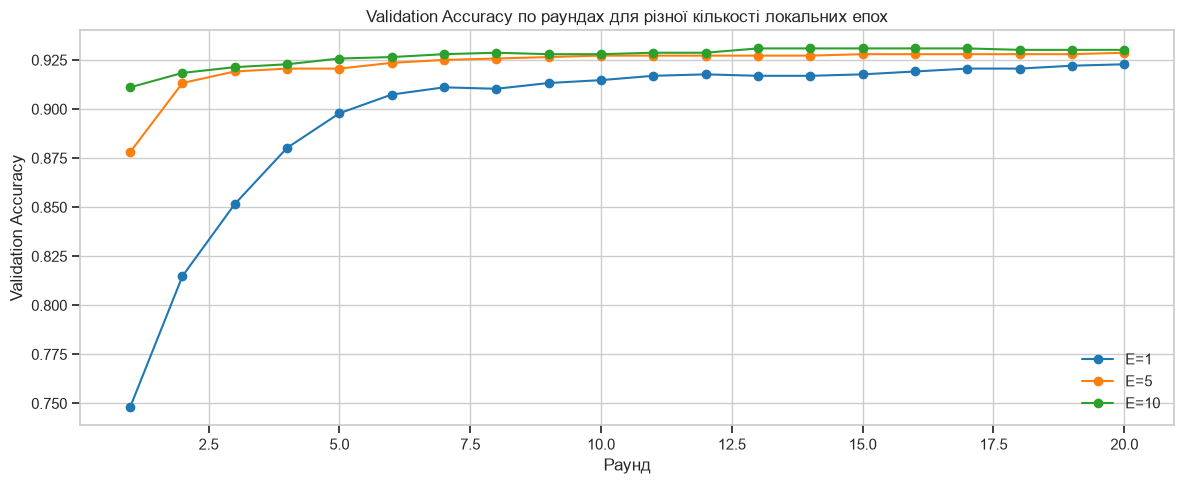

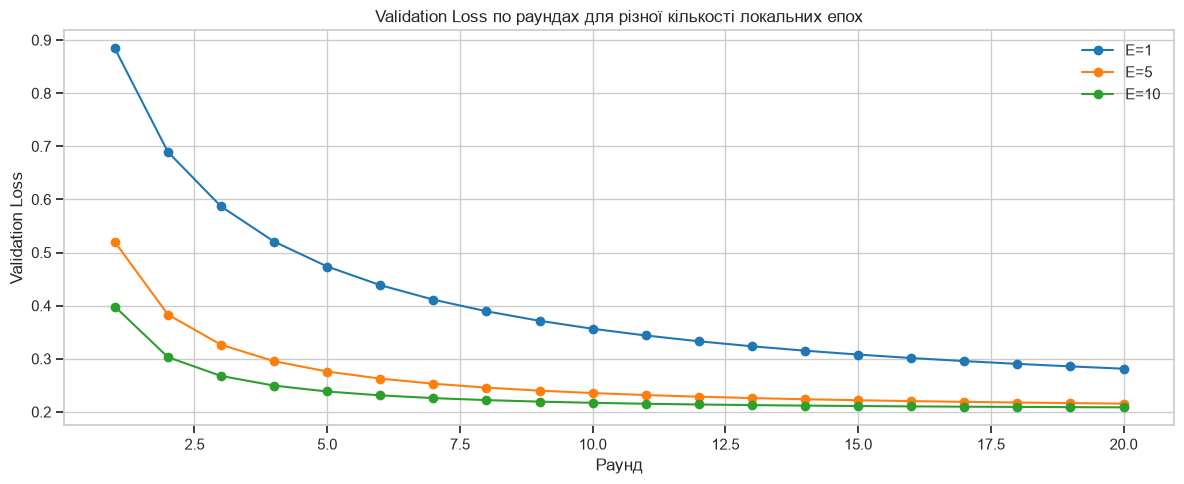

Підсумок Експерименту 2:
 Local Epochs  Accuracy  Macro-F1  Balanced Accuracy  Log Loss
            1    0.9126    0.9256             0.9228    0.3075
            5    0.9177    0.9298             0.9271    0.2444
           10    0.9177    0.9296             0.9271    0.2372


In [33]:
plt.figure(figsize=(12, 5))
for E in local_epoch_values:
    rounds = [entry['round'] for entry in exp2_histories[E]]
    vals = [entry['val_accuracy'] for entry in exp2_histories[E]]
    plt.plot(rounds, vals, marker='o', label=f'E={E}')
plt.title('Validation Accuracy по раундах для різної кількості локальних епох')
plt.xlabel('Раунд')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
for E in local_epoch_values:
    rounds = [entry['round'] for entry in exp2_histories[E]]
    vals = [entry['val_loss'] for entry in exp2_histories[E]]
    plt.plot(rounds, vals, marker='o', label=f'E={E}')
plt.title('Validation Loss по раундах для різної кількості локальних епох')
plt.xlabel('Раунд')
plt.ylabel('Validation Loss')
plt.legend()
plt.tight_layout()
plt.show()

exp2_df = pd.DataFrame(exp2_results)
print("Підсумок Експерименту 2:")
print(exp2_df.round(4).to_string(index=False))

### Висновок

**Швидкість збіжності по раундах.** Графіки чітко демонструють очікуваний ефект: E=1 
стартує з найнижчою validation accuracy (74.8% на 1-му раунді) і повільно, поступово 
наздоганяє E=5 та E=10 лише до ~15–20 раунду. Натомість E=10 стартує одразу з дуже 
високою accuracy (91.1% вже на першому раунді) і практично одразу виходить на плато. 
E=5 займає проміжне положення. Крива Validation Loss показує аналогічну картину: 
E=1 має найвищий початковий loss (0.885) і найповільніше спадання, тоді як E=10 
стартує з loss=0.397 і швидко досягає рівня ~0.21.

**Фінальна якість vs E.** На Global Test: Accuracy = 0.9126 (E=1), 0.9177 (E=5), 
0.9177 (E=10); Log Loss = 0.3075 (E=1), 0.2444 (E=5), 0.2372 (E=10). Отже, E=10 дав 
**кращу** (або принаймні не гіршу) фінальну якість, ніж E=1, хоча теоретично очікується 
протилежний ефект через сильніший client drift при більшому E. Це пояснюється тим, що 
за фіксовані 20 раундів комунікації E=1 виконує лише 20 локальних епох сумарно на 
кожного клієнта, тоді як E=10 виконує 200 — тобто в 10 разів більше обчислювальної 
роботи. На цьому лінійному, опуклому датасеті виграш від значно більшого обсягу 
локального навчання переважує шкоду від client drift: клієнти встигають наблизитись 
до свого локального оптимуму, а зважене усереднення FedAvg усе одно ефективно 
"збирає" ці оптимуми докупи, оскільки для лінійної моделі всі локальні оптимуми 
лежать відносно близько один до одного в просторі параметрів.

Водночас графік Loss показує, що при E=1 модель **не встигає** повністю збігтися 
навіть за 20 раундів (крива продовжує спадати наприкінці), що і пояснює її гірший 
фінальний результат — це не стільки прояв client drift, скільки банальна нестача 
сумарного обсягу навчання.

**Компроміс комунікація-обчислення.** Якщо мережевий трафік є вузьким місцем (наприклад, 
клієнти — мобільні пристрої з обмеженим і дорогим з'єднанням), результати свідчать, що 
E=5 або навіть E=10 є практично виправданим вибором: він дає порівнянну або кращу 
якість за суттєво меншу кількість раундів комунікації порівняно з E=1. Це узгоджується 
з ідеєю FedAvg — жертвувати частиною "чистоти" кожного раунду заради різкого скорочення 
кількості дорогих циклів обміну параметрами між клієнтами й сервером.

**Зв'язок із client drift.** Хоча в цьому конкретному експерименті збільшення E не 
призвело до погіршення фінальної якості, сам механізм client drift концептуально 
присутній: при E=1 кожен клієнт робить лише один прохід по своїх даних перед 
поверненням ваг серверу, залишаючись максимально близько до глобальної моделі $w^t$ — 
це найближче до класичного розподіленого SGD. При зростанні E клієнт встигає сильніше 
підлаштуватися під свій локальний (Non-IID, α=1.0) розподіл даних, перш ніж оновлення 
потрапить на сервер. У нашому випадку негативний вплив цього дрейфу виявився слабшим 
за позитивний ефект від більшого обсягу локальних обчислень — але при сильнішій 
неоднорідності (наприклад, α=0.1) або в нелінійних моделях (глибокі нейромережі) 
баланс міг би зміститися в протилежний бік, і client drift став би домінуючим 
негативним фактором.

## Розділ 10 (опційно): Додатковий експеримент А — Вплив кількості клієнтів K

Фіксуємо α=1.0 (помірна неоднорідність) та E=5 локальних епох, варіюємо кількість 
клієнтів K: 3, 5, 10. Мета — дослідити, як зростання кількості клієнтів (при незмінному 
загальному обсязі даних FL Train Pool) впливає на якість локальних оновлень та стабільність 
агрегації.

Зі зростанням K кожен клієнт у середньому отримує **менше** прикладів (загальний обсяг 
даних фіксований), що робить локальні градієнтні оцінки шумнішими та потенційно посилює 
ефект неоднорідності (менша вибірка на клієнта — вища дисперсія локального розподілу класів).

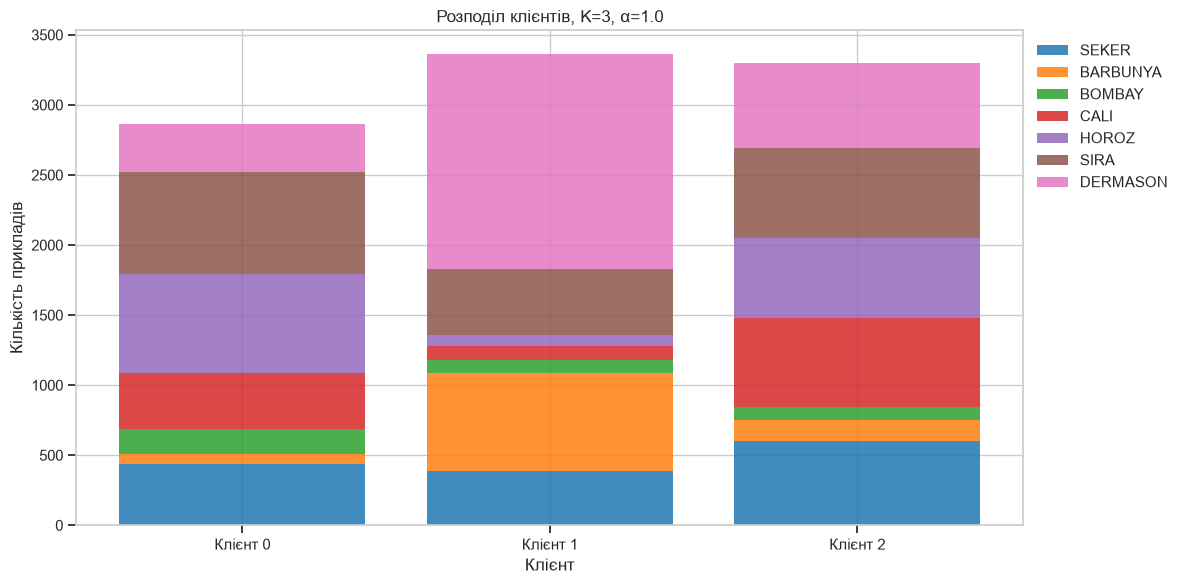

Кількість прикладів на клієнта:
Клієнт 0    2865
Клієнт 1    3363
Клієнт 2    3299
dtype: int64

✓ Усі клієнти мають достатню кількість прикладів (≥ 10).

--- Навчання з K=3 клієнтами ---
Раунд 01: val_loss=0.4001, val_acc=0.9155, val_macro_f1=0.9257
Раунд 02: val_loss=0.3056, val_acc=0.9199, val_macro_f1=0.9321
Раунд 03: val_loss=0.2692, val_acc=0.9229, val_macro_f1=0.9348
Раунд 04: val_loss=0.2500, val_acc=0.9251, val_macro_f1=0.9370
Раунд 05: val_loss=0.2381, val_acc=0.9258, val_macro_f1=0.9378
Раунд 06: val_loss=0.2301, val_acc=0.9265, val_macro_f1=0.9397
Раунд 07: val_loss=0.2243, val_acc=0.9258, val_macro_f1=0.9387
Раунд 08: val_loss=0.2201, val_acc=0.9258, val_macro_f1=0.9387
Раунд 09: val_loss=0.2168, val_acc=0.9251, val_macro_f1=0.9378
Раунд 10: val_loss=0.2142, val_acc=0.9251, val_macro_f1=0.9378
Раунд 11: val_loss=0.2121, val_acc=0.9258, val_macro_f1=0.9381
Раунд 12: val_loss=0.2103, val_acc=0.9265, val_macro_f1=0.9386
Раунд 13: val_loss=0.2089, val_acc=0.9258, val_macro_f1=

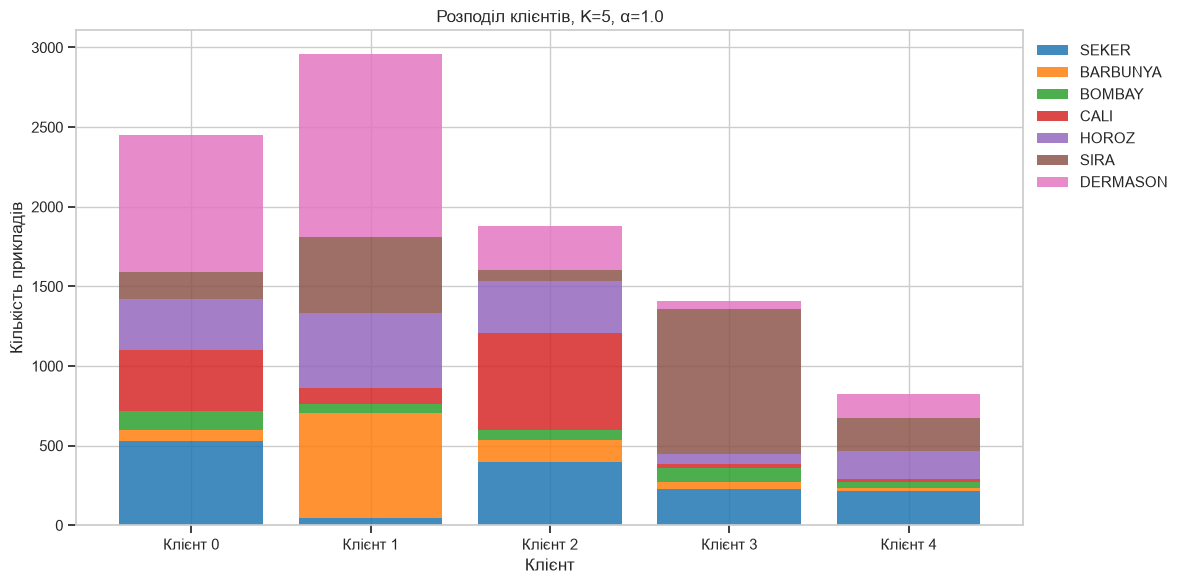

Кількість прикладів на клієнта:
Клієнт 0    2449
Клієнт 1    2959
Клієнт 2    1882
Клієнт 3    1411
Клієнт 4     826
dtype: int64

✓ Усі клієнти мають достатню кількість прикладів (≥ 10).

--- Навчання з K=5 клієнтами ---
Раунд 01: val_loss=0.5200, val_acc=0.8780, val_macro_f1=0.8919
Раунд 02: val_loss=0.3832, val_acc=0.9133, val_macro_f1=0.9252
Раунд 03: val_loss=0.3264, val_acc=0.9192, val_macro_f1=0.9314
Раунд 04: val_loss=0.2954, val_acc=0.9206, val_macro_f1=0.9322
Раунд 05: val_loss=0.2760, val_acc=0.9206, val_macro_f1=0.9329
Раунд 06: val_loss=0.2627, val_acc=0.9236, val_macro_f1=0.9357
Раунд 07: val_loss=0.2530, val_acc=0.9251, val_macro_f1=0.9371
Раунд 08: val_loss=0.2457, val_acc=0.9258, val_macro_f1=0.9376
Раунд 09: val_loss=0.2400, val_acc=0.9265, val_macro_f1=0.9386
Раунд 10: val_loss=0.2354, val_acc=0.9273, val_macro_f1=0.9391
Раунд 11: val_loss=0.2317, val_acc=0.9273, val_macro_f1=0.9391
Раунд 12: val_loss=0.2286, val_acc=0.9273, val_macro_f1=0.9384
Раунд 13: val_loss=0.2

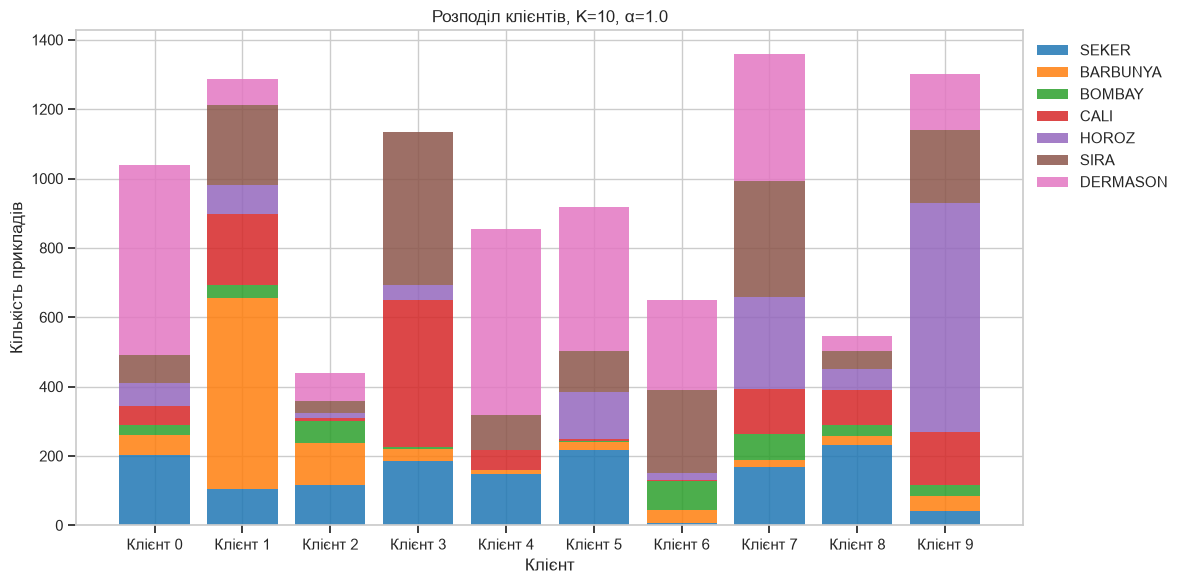

Кількість прикладів на клієнта:
Клієнт 0    1038
Клієнт 1    1287
Клієнт 2     438
Клієнт 3    1135
Клієнт 4     855
Клієнт 5     917
Клієнт 6     649
Клієнт 7    1359
Клієнт 8     547
Клієнт 9    1302
dtype: int64

✓ Усі клієнти мають достатню кількість прикладів (≥ 10).

--- Навчання з K=10 клієнтами ---
Раунд 01: val_loss=0.6762, val_acc=0.8773, val_macro_f1=0.8732
Раунд 02: val_loss=0.4988, val_acc=0.9008, val_macro_f1=0.9089
Раунд 03: val_loss=0.4170, val_acc=0.9111, val_macro_f1=0.9212
Раунд 04: val_loss=0.3694, val_acc=0.9126, val_macro_f1=0.9227
Раунд 05: val_loss=0.3382, val_acc=0.9155, val_macro_f1=0.9275
Раунд 06: val_loss=0.3162, val_acc=0.9177, val_macro_f1=0.9301
Раунд 07: val_loss=0.2999, val_acc=0.9221, val_macro_f1=0.9347
Раунд 08: val_loss=0.2873, val_acc=0.9258, val_macro_f1=0.9380
Раунд 09: val_loss=0.2773, val_acc=0.9273, val_macro_f1=0.9389
Раунд 10: val_loss=0.2691, val_acc=0.9265, val_macro_f1=0.9381
Раунд 11: val_loss=0.2623, val_acc=0.9287, val_macro_f1=0.9396

In [34]:
alpha = 1.0
num_rounds = 20
local_epochs = 5
lr = 0.1
batch_size = 64
l2_lambda = 0.001
client_counts = [3, 5, 10]

expA_results = []
expA_histories = {}

for K in client_counts:
    client_dict = partition_dirichlet(X_train_pool, y_train_pool, num_clients=K,
                                       alpha=alpha, random_state=RANDOM_STATE)
    visualize_client_distributions(client_dict, f'Розподіл клієнтів, K={K}, α={alpha}')

    print(f"\n--- Навчання з K={K} клієнтами ---")
    W_global, b_global, history = federated_train(
        client_dict, X_val, y_val, Y_val,
        num_rounds=num_rounds, local_epochs=local_epochs,
        lr=lr, batch_size=batch_size, l2_lambda=l2_lambda,
    )
    expA_histories[K] = history

    model = SoftmaxLogisticRegression(learning_rate=lr, epochs=1, batch_size=batch_size,
                                       l2_lambda=l2_lambda, random_state=RANDOM_STATE)
    model.set_params(W_global, b_global)
    metrics = evaluate_model(model, X_test, y_test_int, id_to_class)

    expA_results.append({
        'K': K,
        'Accuracy': metrics['Accuracy'],
        'Macro-F1': metrics['Macro-F1'],
        'Balanced Accuracy': metrics['Balanced Accuracy'],
        'Log Loss': metrics['Log Loss'],
    })

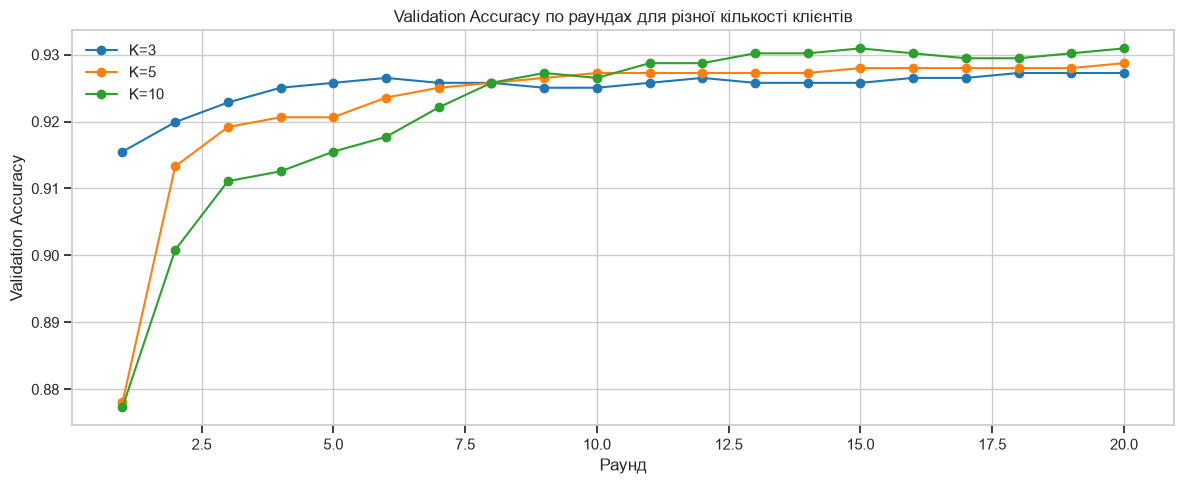

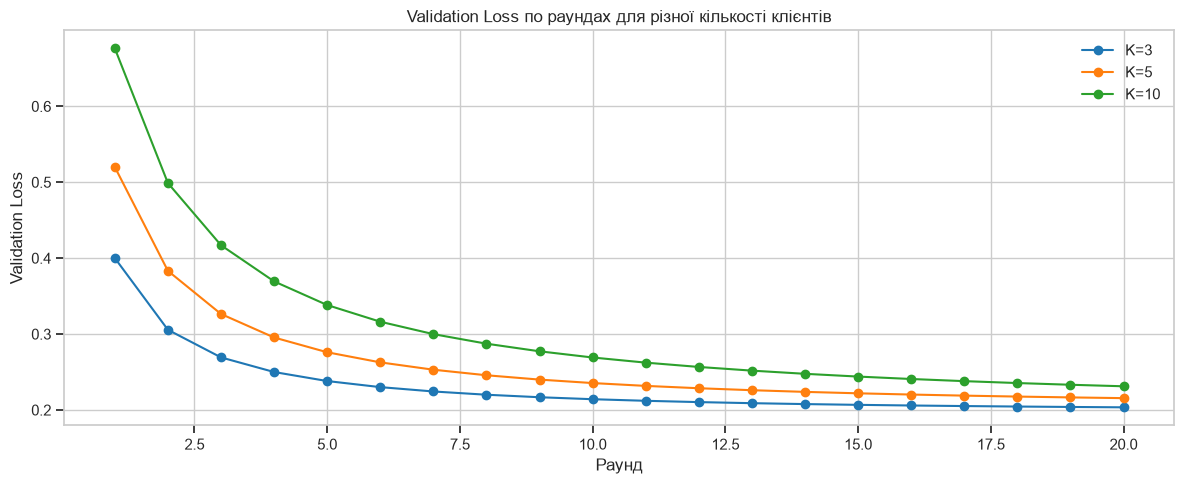

Підсумок Експерименту А:
 K  Accuracy  Macro-F1  Balanced Accuracy  Log Loss
 3    0.9185    0.9309             0.9285    0.2353
 5    0.9177    0.9298             0.9271    0.2444
10    0.9130    0.9259             0.9234    0.2624


In [35]:
plt.figure(figsize=(12, 5))
for K in client_counts:
    rounds = [entry['round'] for entry in expA_histories[K]]
    vals = [entry['val_accuracy'] for entry in expA_histories[K]]
    plt.plot(rounds, vals, marker='o', label=f'K={K}')
plt.title('Validation Accuracy по раундах для різної кількості клієнтів')
plt.xlabel('Раунд')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
for K in client_counts:
    rounds = [entry['round'] for entry in expA_histories[K]]
    vals = [entry['val_loss'] for entry in expA_histories[K]]
    plt.plot(rounds, vals, marker='o', label=f'K={K}')
plt.title('Validation Loss по раундах для різної кількості клієнтів')
plt.xlabel('Раунд')
plt.ylabel('Validation Loss')
plt.legend()
plt.tight_layout()
plt.show()

expA_df = pd.DataFrame(expA_results)
print("Підсумок Експерименту А:")
print(expA_df.round(4).to_string(index=False))

### Висновок

* **Розподіл даних при різних $K$.** Кількість прикладів на клієнта закономірно зменшується зі зростанням $K$: при $K=3$ кожен клієнт має 2865–3363 приклади (відносно збалансовано), при $K=5$ — 826–2959 (уже помітний розкид), а при $K=10$ — від 438 (Клієнт 2) до 1359 (Клієнт 7), тобто різниця більш ніж утричі. Менший обсяг даних на клієнта при більшому $K$ означає статистично шумніші локальні оцінки та потенційно сильніший відносний дисбаланс класів усередині кожного клієнта.

* **Динаміка збіжності.** Чим більше $K$, тим повільніший і «шумніший» старт: перший раунд дає $\text{val\_accuracy} = 0.9155$ ($K=3$), $0.8780$ ($K=5$) і лише $0.8773$ ($K=10$). Це логічно — при $K=10$ кожен локальний клієнт навчається на дуже малій і сильніше зміщеній вибірці, тому перше глобальне усереднення дає гіршу початкову модель. Цікаво, що при цьому $K=10$ демонструє найвищу validation accuracy на 20-му раунді ($0.9309$) серед усіх трьох конфігурацій, перевершуючи навіть $K=3$ ($0.9273$) — тобто, попри повільніший старт, за 20 раундів модель із $K=10$ встигає «наздогнати» й навіть перевищити результати з меншою кількістю клієнтів на самій Validation-вибірці.

* **Фінальна якість vs $K$ (на Global Test).** Тут картина протилежна: Accuracy $= 0.9185$ ($K=3$) $\rightarrow 0.9177$ ($K=5$) $\rightarrow 0.9130$ ($K=10$), і аналогічно Log Loss зростає з $0.2353$ до $0.2624$. Тобто на Test, на відміну від Validation, спостерігається чіткий монотонний спад якості зі збільшенням кількості клієнтів.

* **Розбіжність між Validation і Test — важливе спостереження.** Те, що $K=10$ виграє на Validation, але програє на Test, ймовірно вказує на легке перенавчання глобальної моделі під конкретний Global Validation набір при більшій кількості раундів агрегації дрібних, зашумлених клієнтських оновлень: усереднення великої кількості малих, індивідуально зміщених локальних моделей могло «підлаштуватися» під специфічні особливості саме Validation-вибірки статистично випадковим чином, що не узагальнюється так само добре на незалежний Global Test. Це наочно підтверджує методичну важливість того, що фінальна оцінка виконується строго на окремому, «незайманому» Global Test, а не на Validation, який використовувався для проміжного моніторингу.

* **Пояснення ефекту.** Зі збільшенням кількості клієнтів при фіксованому загальному обсязі FL Train Pool кожен клієнт отримує менше прикладів, що спричиняє:
  1. Локальні градієнтні оцінки стають статистично шумнішими (менша вибірка $\rightarrow$ вища дисперсія оцінки).
  2. Локальний розподіл класів у кожного клієнта стає потенційно ще сильніше зміщеним відносно глобального (за того ж $\alpha$ менша вибірка дає більшу відносну варіацію фактичних пропорцій класів).

  Це узгоджується зі спостереженою тенденцією гіршої фінальної якості на Test при $K=10$. Водночас більша кількість клієнтів означає більше незалежних «голосів» в агрегації FedAvg, що частково компенсує шум — цим, ймовірно, пояснюється те, чому $K=10$ усе ж показує сильну (хоч і оманливо високу) якість на Validation.


## Розділ 11: Тристороннє порівняння моделей

Порівнюємо три типи моделей на **однаковому** Global Test:

1. **Централізована модель** — навчена на всьому FL Train Pool (baseline, розділ 6).
2. **Глобальна федеративна модель** — найкраща конфігурація FedAvg (K=5, α=1.0, E=5, 
   20 раундів), отримана шляхом агрегації клієнтських оновлень.
3. **Локальні клієнтські моделі** — моделі, навчені **окремо, без федерації**, лише на 
   даних свого клієнта (той самий розподіл K=5, α=1.0), і оцінені на тому самому 
   Global Test.

Порівняння локальних моделей саме на Global Test (а не на локальних тестових наборах 
кожного клієнта) наочно демонструє: чи здатна модель, що "бачила" лише вузьку, зміщену 
підмножину класів, узагальнювати на повний, збалансований розподіл даних.

In [36]:
# Той самий розподіл, що дав найкращі результати у попередніх експериментах: K=5, alpha=1.0
best_dict = partition_dirichlet(X_train_pool, y_train_pool, num_clients=5,
                                 alpha=1.0, random_state=RANDOM_STATE)

print("--- Навчання найкращої федеративної моделі (K=5, α=1.0, E=5) ---")
W_best, b_best, best_history = federated_train(
    best_dict, X_val, y_val, Y_val,
    num_rounds=20, local_epochs=5, lr=0.1, batch_size=64, l2_lambda=0.001,
)

fed_model = SoftmaxLogisticRegression(learning_rate=0.1, epochs=1, batch_size=64,
                                       l2_lambda=0.001, random_state=RANDOM_STATE)
fed_model.set_params(W_best, b_best)

central_metrics = evaluate_model(final_central_model, X_test, y_test_int, id_to_class)
fed_metrics = evaluate_model(fed_model, X_test, y_test_int, id_to_class)

--- Навчання найкращої федеративної моделі (K=5, α=1.0, E=5) ---
Раунд 01: val_loss=0.5200, val_acc=0.8780, val_macro_f1=0.8919
Раунд 02: val_loss=0.3832, val_acc=0.9133, val_macro_f1=0.9252
Раунд 03: val_loss=0.3264, val_acc=0.9192, val_macro_f1=0.9314
Раунд 04: val_loss=0.2954, val_acc=0.9206, val_macro_f1=0.9322
Раунд 05: val_loss=0.2760, val_acc=0.9206, val_macro_f1=0.9329
Раунд 06: val_loss=0.2627, val_acc=0.9236, val_macro_f1=0.9357
Раунд 07: val_loss=0.2530, val_acc=0.9251, val_macro_f1=0.9371
Раунд 08: val_loss=0.2457, val_acc=0.9258, val_macro_f1=0.9376
Раунд 09: val_loss=0.2400, val_acc=0.9265, val_macro_f1=0.9386
Раунд 10: val_loss=0.2354, val_acc=0.9273, val_macro_f1=0.9391
Раунд 11: val_loss=0.2317, val_acc=0.9273, val_macro_f1=0.9391
Раунд 12: val_loss=0.2286, val_acc=0.9273, val_macro_f1=0.9384
Раунд 13: val_loss=0.2260, val_acc=0.9273, val_macro_f1=0.9383
Раунд 14: val_loss=0.2238, val_acc=0.9273, val_macro_f1=0.9383
Раунд 15: val_loss=0.2219, val_acc=0.9280, val_macro_

Навчання локальних моделей + збір таблиці

In [37]:
rows = [
    {
        'Тип моделі': 'Централізована',
        'Розподіл / Клієнт': 'Весь FL Train Pool',
        'Accuracy': central_metrics['Accuracy'],
        'Macro-F1': central_metrics['Macro-F1'],
        'Balanced Accuracy': central_metrics['Balanced Accuracy'],
        'Log Loss': central_metrics['Log Loss'],
    },
    {
        'Тип моделі': 'Федеративна (глобальна)',
        'Розподіл / Клієнт': 'K=5, α=1.0',
        'Accuracy': fed_metrics['Accuracy'],
        'Macro-F1': fed_metrics['Macro-F1'],
        'Balanced Accuracy': fed_metrics['Balanced Accuracy'],
        'Log Loss': fed_metrics['Log Loss'],
    },
]

for cid in sorted(best_dict.keys()):
    client = best_dict[cid]
    X_local = client['X']
    y_local = client['y']

    Y_local = np.zeros((len(y_local), len(class_to_id)), dtype=np.float64)
    for i, label in enumerate(y_local):
        Y_local[i, class_to_id[label]] = 1.0

    # Локальна модель: та ж кількість епох, що й локальне навчання клієнта у FedAvg (E=5),
    # але БЕЗ федеративної агрегації - модель навчається і залишається "наодинці".
    local_model = SoftmaxLogisticRegression(learning_rate=0.1, epochs=5, batch_size=64,
                                             l2_lambda=0.001, random_state=RANDOM_STATE)
    local_model.fit(X_local, Y_local)

    local_metrics = evaluate_model(local_model, X_test, y_test_int, id_to_class)
    rows.append({
        'Тип моделі': 'Локальна',
        'Розподіл / Клієнт': f'Клієнт {cid}',
        'Accuracy': local_metrics['Accuracy'],
        'Macro-F1': local_metrics['Macro-F1'],
        'Balanced Accuracy': local_metrics['Balanced Accuracy'],
        'Log Loss': local_metrics['Log Loss'],
    })

comparison_df = pd.DataFrame(rows)
print("Тристороннє порівняння моделей на Global Test:")
print(comparison_df.round(4).to_string(index=False))

Тристороннє порівняння моделей на Global Test:
             Тип моделі  Розподіл / Клієнт  Accuracy  Macro-F1  Balanced Accuracy  Log Loss
         Централізована Весь FL Train Pool    0.9196    0.9315             0.9302    0.2195
Федеративна (глобальна)         K=5, α=1.0    0.9177    0.9298             0.9271    0.2444
               Локальна           Клієнт 0    0.7393    0.7077             0.7570    0.6209
               Локальна           Клієнт 1    0.7393    0.7354             0.7469    0.6379
               Локальна           Клієнт 2    0.7429    0.7210             0.7800    0.6960
               Локальна           Клієнт 3    0.5031    0.4646             0.5729    1.2246
               Локальна           Клієнт 4    0.6926    0.5411             0.6537    0.8302


Confusion matrices для наочного порівняння

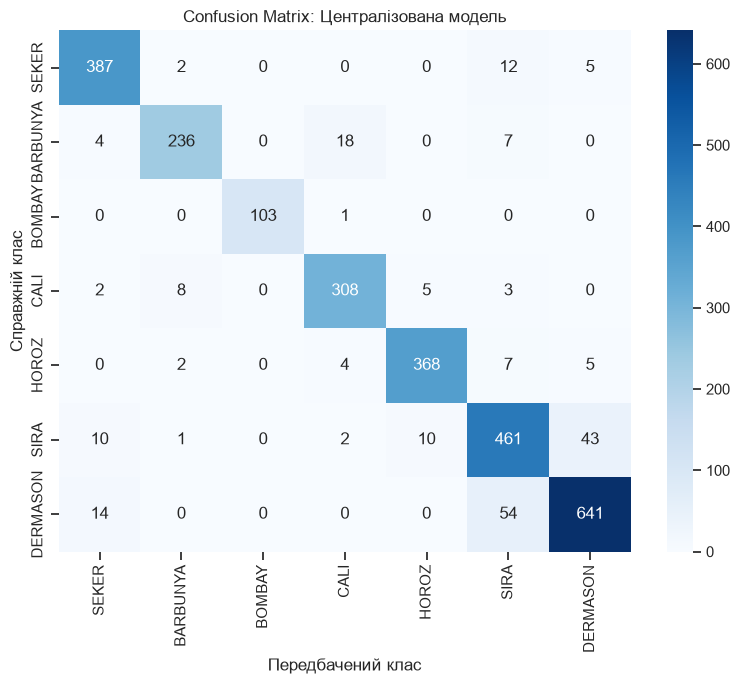

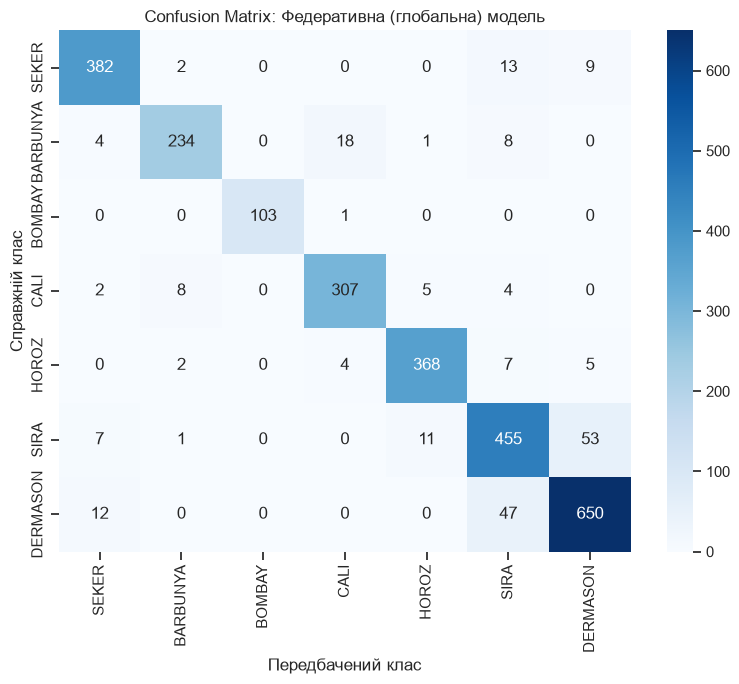

In [38]:
plot_confusion_matrix(central_metrics['Confusion Matrix'], list(id_to_class.values()),
                       'Confusion Matrix: Централізована модель')
plot_confusion_matrix(fed_metrics['Confusion Matrix'], list(id_to_class.values()),
                       'Confusion Matrix: Федеративна (глобальна) модель')

### Висновок

**Централізована vs федеративна модель.** Результати дуже близькі: Accuracy = 0.9196 
(централізована) проти 0.9177 (федеративна) — різниця всього ~0.2 в.п. Аналогічно 
Macro-F1 (0.9315 vs 0.9298) та Balanced Accuracy (0.9302 vs 0.9271) практично збігаються, 
а Log Loss дещо вищий у федеративної моделі (0.2444 vs 0.2195), що очікувано — 
агрегація параметрів через усереднення природно дає трохи менш "впевнені" (гірше 
каліброві) ймовірності, ніж пряма оптимізація на об'єднаних даних. Загалом федеративна 
модель **практично наздоганяє** централізовану, не отримуючи жодного прямого доступу 
до сирих даних клієнтів — лише до агрегованих параметрів моделі.

**Локальні моделі.** Тут контраст разючий: усі п'ять локальних моделей суттєво 
поступаються і централізованій, і федеративній моделі. Найкращі локальні результати 
(Клієнти 0–2) дають Accuracy ≈ 0.74, що на ~18 в.п. гірше за федеративну модель. 
Найгірший результат — у **Клієнта 3** (Accuracy = 0.5031, Log Loss = 1.2246) — це 
драматичне падіння якості пояснюється розподілом даних цього клієнта (розділ 7, K=5, 
α=1.0): Клієнт 3 отримав найменше даних (1411 прикладів) і його вибірка майже цілком 
домінована одним класом (SIRA), тому локальна модель фактично не бачила достатньо 
прикладів інших 6 класів і не змогла навчитися їх розрізняти. Клієнт 4 (Accuracy=0.6926) 
демонструє схожу, хоч і менш екстремальну проблему — його дані доміновані HOROZ та SIRA. 
Натомість Клієнти 0–2, чиї локальні розподіли дещо більш різноманітні (хоч і теж 
зміщені), показують відносно кращі, хоча все одно далекі від прийнятних, результати.

**Головний висновок.** Федеративне навчання дозволяє досягти якості, практично ідентичної 
до централізованого навчання (різниця в межах 0.2–0.3 в.п. за основними метриками), 
**не передаючи серверу жодних сирих даних клієнтів** — лише параметри моделі. Локальні 
моделі окремих клієнтів систематично й суттєво поступаються і централізованій, і 
федеративній моделі на повному тестовому наборі (від 15 до понад 40 в.п. Accuracy), 
оскільки кожна з них "бачить" лише вузьку, зміщену підмножину класів і не здатна 
узагальнювати на класи, відсутні або рідкісні в її локальних даних. Це наочно демонструє 
ключову цінність агрегації FedAvg: об'єднання знань кількох вузько спеціалізованих 
локальних моделей через зважене усереднення параметрів дає модель, що узагальнює 
кардинально краще за кожну окрему з них, зберігаючи при цьому приватність вихідних даних.

## Розділ 12: Теоретичні питання

**1. Чому для багатокласової класифікації використовують softmax?**
Softmax перетворює вектор довільних дійсних чисел (логітів) у розподіл ймовірностей, 
що сумується до 1 по всіх класах. Це багатокласовий аналог сигмоїди в бінарній логістичній 
регресії — дозволяє інтерпретувати вихід моделі як категоріальний розподіл над класами.

**2. Чому крос-ентропія є природною функцією втрат для логістичної регресії?**
Крос-ентропія дорівнює від'ємному логарифму правдоподібності правильного класу за моделлю. 
Мінімізація крос-ентропії еквівалентна максимізації правдоподібності (Maximum Likelihood 
Estimation), що є теоретично обґрунтованим підходом до оцінки параметрів імовірнісної моделі.

**3. Чим відрізняється Ridge-регуляризація від Lasso-регуляризації?**
Ridge (L2) додає штраф, пропорційний квадрату норми ваг — плавно "стискає" всі ваги, 
ніколи не занулюючи їх повністю. Lasso (L1) додає штраф, пропорційний модулю ваг, і здатний 
занулювати окремі ваги повністю, створюючи розріджені (sparse) моделі з неявним відбором ознак.

**4. Чому параметр зміщення b зазвичай не регуляризують?**
b зсуває поріг рішення і не пов'язаний з масштабом ознак — його регуляризація штучно 
обмежувала б здатність моделі коректно позиціонувати базовий рівень ймовірностей класів, 
не даючи жодного виграшу в стабільності (на відміну від W, де регуляризація протидіє 
мультиколінеарності ознак).

**5. Що таке Data Leakage?**
Це ненавмисне потрапляння інформації з валідаційної/тестової вибірки в процес навчання — 
через масштабування, кодування, відбір ознак чи підбір гіперпараметрів, обчислені на 
даних, що включають ці вибірки. Призводить до оптимістично завищених, оманливих метрик.

**6. Чому тестову вибірку не можна використовувати для підбору гіперпараметрів?**
Тестова вибірка має бути незалежним, "чесним" мірилом узагальнювальної здатності моделі. 
Якщо на ній підбирати гіперпараметри, модель неявно "підлаштовується" під тест, і 
підсумкові метрики перестають відображати реальну якість на справді нових даних.

**7. Чому параметри масштабування потрібно навчати лише на тренувальних даних?**
Середнє й дисперсія мають відображати розподіл саме тренувальних даних. Якщо їх рахувати 
на об'єднанні з валідацією/тестом, ці вибірки "просочують" інформацію про себе в 
препроцесинг ще до оцінювання моделі — це форма Data Leakage.

**8. Що таке федеративне навчання і які його основні переваги?**
Розподілена парадигма навчання, де клієнти тренують локальні моделі на приватних даних 
і надсилають серверу лише оновлення параметрів (не самі дані). Переваги: збереження 
приватності, зниження витрат на передачу великих обсягів сирих даних, можливість 
використовувати розподілені, гетерогенні джерела даних без їх централізації.

**9. Чому сервер не повинен отримувати сирі дані клієнтів?**
Передача сирих даних розкриває потенційно чутливу інформацію, збільшує витрати на 
комунікацію та може порушувати вимоги приватності/законодавства. Обмін лише агрегованими 
параметрами моделі є значно менш інвазивною альтернативою.

**10. Чому агрегація FedAvg зважує клієнтів за кількістю прикладів?**
Клієнти з більшою кількістю прикладів дають статистично надійніші (менш шумні) оцінки 
локального градієнта. Зважування пропорційно до $n_k$ апроксимує мінімізацію втрат так, 
ніби модель навчалась централізовано на об'єднанні всіх локальних даних.

**11. Що станеться, якщо агрегувати параметри клієнтів без зважування?**
Клієнт із 50 прикладами матиме такий самий вплив на глобальну модель, як клієнт із 5000 — 
це спотворює модель у бік малих, статистично ненадійних клієнтів і відхиляється від 
справжньої мети мінімізації втрат на об'єднаному розподілі даних.

**12. Що таке Non-IID дані?**
Дані, локальний розподіл яких відрізняється між клієнтами — наприклад, різні пропорції 
класів (label skew) чи різні розподіли ознак у різних клієнтів, на відміну від IID, де 
кожен клієнт має статистично репрезентативну "мініатюру" глобального розподілу.

**13. Чому федеративне навчання може погіршуватись на Non-IID даних?**
Кожен клієнт оптимізує свій локальний, зміщений об'єктив. Усереднення різноспрямованих 
локальних градієнтів/параметрів дає гіршу апроксимацію справжнього глобального градієнта, 
ніж при IID, що уповільнює збіжність і потенційно погіршує фінальну якість (підтверджено 
в Експерименті 1: вищий Log Loss при меншому α).

**14. Що таке клієнтський дрейф (client drift)?**
Надмірне відхилення параметрів локальної моделі клієнта від поточної глобальної моделі 
після кількох кроків локальної оптимізації — особливо виражене при Non-IID даних, коли 
локальний оптимум клієнта суттєво відрізняється від глобального.

**15. Як кількість локальних епох впливає на глобальну модель?**
Більше локальних епох (E) знижує частоту комунікації (менше раундів потрібно), але 
посилює потенційний client drift. У нашому Експерименті 2 цей негативний ефект виявився 
слабшим за позитивний ефект від більшого обсягу локальних обчислень — більше E дало 
кращу фінальну якість, оскільки лінійна модель стійка до помірного дрейфу.

**16. Чи може глобальна модель бути гіршою за централізовану? Чому?**
Так. Централізована модель безпосередньо мінімізує втрати на об'єднаних даних єдиним 
узгодженим градієнтним спуском. Федеративна модель — це лише наближення через 
усереднення окремо оптимізованих локальних моделей. У наших експериментах різниця була 
невеликою (~0.2–0.3 в.п.) через лінійну природу моделі, але при сильнішій неоднорідності 
чи нелінійних моделях розрив може бути значно більшим.

**17. Які метрики краще використовувати для багатокласової класифікації з дисбалансом?**
Accuracy проста, але оманлива при дисбалансі (модель може ігнорувати рідкісні класи й 
все одно мати високу Accuracy). Macro-F1 та Balanced Accuracy надійніші, оскільки 
оцінюють якість по кожному класу окремо з рівною вагою. Log Loss корисний для оцінки 
каліброваності ймовірностей. Confusion Matrix дає детальну картину помилок між 
конкретними парами класів.

## Загальний висновок

У цій роботі було реалізовано багатокласову логістичну регресію (softmax-регресію) 
повністю засобами numpy — включно з векторизованим обчисленням softmax, крос-ентропійної 
функції втрат із Ridge-регуляризацією, градієнтів та mini-batch градієнтного спуску.

**Централізована базова модель**, підібрана через grid search на Global Validation 
(lr=0.1, batch_size=64, l2_lambda=0.0), досягла на Global Test Accuracy=0.9196, 
Macro-F1=0.9315 — це показало, що навіть проста лінійна модель добре справляється з 
розпізнаванням сортів квасолі за геометричними ознаками, попри виражену мультиколінеарність.

**Федеративне навчання (FedAvg)** було реалізовано з коректним розподілом ролей сервера 
й клієнтів: сервер не має доступу до сирих даних, лише до параметрів моделей та Global 
Validation/Test. Було досліджено IID та Non-IID (Dirichlet) розподіли даних між клієнтами 
з детальною візуалізацією та перевіркою на мінімальний розмір вибірки клієнта.

Ключові емпіричні результати:
- Найкраща федеративна конфігурація (K=5, α=1.0, E=5, 20 раундів) досягла Accuracy=0.9177 — 
  практично на рівні централізованої моделі (різниця ~0.2 в.п.), підтверджуючи, що FedAvg 
  дозволяє зберегти якість моделі без централізації даних.
- **Вплив неоднорідності (α)** виявився відносно слабким для цієї лінійної, опуклої задачі: 
  Accuracy знизилась лише на ~0.15 в.п. при переході від α=5.0 до α=0.3, хоча уповільнення 
  збіжності (вищий Loss на ранніх раундах) було помітним.
- **Вплив кількості локальних епох (E)** показав контрінтуїтивний результат: більше E 
  (10 проти 1) дало кращу фінальну якість за фіксовану кількість раундів, оскільки виграш 
  від більшого обсягу локальних обчислень переважив шкоду від client drift.
- **Вплив кількості клієнтів (K)** продемонстрував чіткий монотонний спад якості на Test 
  зі зростанням K (0.9185 → 0.9130 для K=3→10), пов'язаний зі зменшенням і зашумленням 
  локальних вибірок; водночас на Validation спостерігалась протилежна тенденція, що 
  підкреслює важливість використання незалежного Test для фінальної оцінки.
- **Порівняння з локальними моделями** виявилось найпоказовішим: ізольовані локальні 
  моделі окремих клієнтів суттєво поступалися і централізованій, і федеративній моделі 
  (до 40+ в.п. Accuracy для найгіршого клієнта), оскільки кожна з них навчалась лише на 
  вузькій, зміщеній підмножині класів.

**Головний висновок роботи:** федеративне навчання є ефективним компромісом між 
приватністю даних і якістю моделі — агрегація FedAvg дозволяє отримати модель, що 
узагальнює істотно краще за будь-яку окрему локальну модель і практично не поступається 
централізованому підходу, за умови розумного вибору гіперпараметрів (кількості клієнтів, 
локальних епох) відповідно до ступеня неоднорідності даних. Для лінійних моделей, як 
показано в цій роботі, стійкість до Non-IID даних та client drift виявляється вищою, 
ніж це зазвичай очікується в літературі, орієнтованій переважно на глибокі нейромережі.